In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from glob import glob
from scipy import signal
from check_time import extract_vars
import seaborn as sns

In [2]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

## Ozone response after eruptions

Also comparing ozone to the AOD, timeseries of anomalies, in case I see something exciting.

In [3]:
cb_O3_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/cb_O3_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in cb_O3_19['time'].values])
cb_O3_19 = cb_O3_19.assign_coords(time=shifted_time_19)
cb_O3_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/cb_O3_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in cb_O3_19_c['time'].values])
cb_O3_19_c = cb_O3_19_c.assign_coords(time=shifted_time_19_c)
cb_O3_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/cb_O3_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in cb_O3_22['time'].values])
cb_O3_22 = cb_O3_22.assign_coords(time=shifted_time_22)
cb_O3_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/cb_O3_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in cb_O3_24['time'].values])
cb_O3_24 = cb_O3_24.assign_coords(time=shifted_time_24)
cb_O3_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in cb_O3_1825_17tg['time'].values])
cb_O3_1825_17tg = cb_O3_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
cb_O3_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/cb_O3_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in cb_O3_1825['time'].values])
cb_O3_1825 = cb_O3_1825.assign_coords(time=shifted_time_1825)
cb_O3_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/cb_O3_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in cb_O3_1tg['time'].values])
cb_O3_1tg = cb_O3_1tg.assign_coords(time=shifted_time_1tg)
cb_O3_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/cb_O3_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in cb_O3_1pr['time'].values])
cb_O3_1pr = cb_O3_1pr.assign_coords(time=shifted_time_1pr)
cb_O3_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/cb_O3_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in cb_O3_60tg['time'].values])
cb_O3_60tg = cb_O3_60tg.assign_coords(time=shifted_time_60tg)

In [4]:
lat = cb_O3_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat = cb_O3_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = cb_O3_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = cb_O3_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = cb_O3_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = cb_O3_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = cb_O3_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = cb_O3_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = cb_O3_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

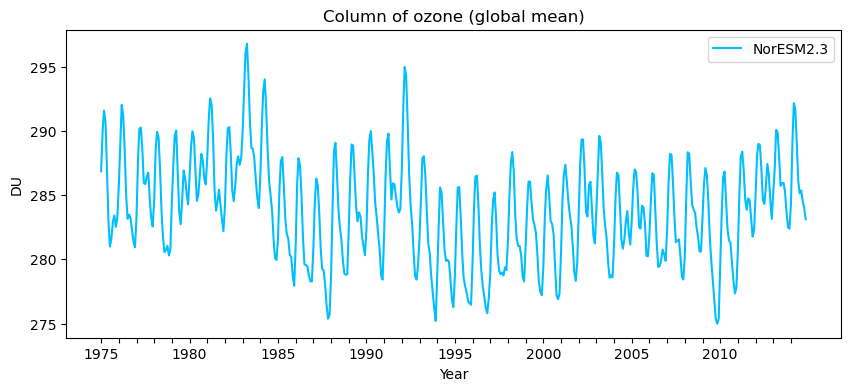

In [5]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = cb_O3_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(10, 4))
o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("Column of ozone (global mean)")
plt.legend()
plt.show()

In [6]:
def calc_anomaly(ds, weights, baseline_obj, lat_range=None):
    var = "cb_O3" 
    
    if lat_range:
        data = ds[var].sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = ds[var]
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"]) * DU
    anom = mean_ts.groupby("time.month") - baseline_obj
    return anom.sel(time=slice('1991-01-01', '1996-01-01'))

In [7]:
# Global
o3_glob = cb_O3_19["cb_O3"].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
base_global = o3_glob.sel(time=slice("1986", "1990")).groupby("time.month").mean()

# Tropics
o3_trop = cb_O3_19["cb_O3"].sel(lat=slice(-20,20)).weighted(weighted_lat.sel(lat=slice(-20,20))).mean(dim=["lat", "lon"]) * DU
base_trop = o3_trop.sel(time=slice("1986", "1990")).groupby("time.month").mean()

In [8]:
o3_anom = calc_anomaly(cb_O3_19, weighted_lat, base_global)
o3_anom = o3_anom.sel(time=slice("1991", "1996"))
o3_19_c_anom = calc_anomaly(cb_O3_19_c, weighted_lat_19_c, base_global)
o3_22_anom = calc_anomaly(cb_O3_22, weighted_lat_22, base_global)
o3_24_anom = calc_anomaly(cb_O3_24, weighted_lat_24, base_global)
o3_1825_anom = calc_anomaly(cb_O3_1825, weighted_lat_1825, base_global)
o3_1825_17tg_anom = calc_anomaly(cb_O3_1825_17tg, weighted_lat_1825_17tg, base_global)
o3_1pr_anom = calc_anomaly(cb_O3_1pr, weighted_lat_1pr, base_global)
o3_1tg_anom = calc_anomaly(cb_O3_1tg, weighted_lat_1tg, base_global)
o3_60tg_anom = calc_anomaly(cb_O3_60tg, weighted_lat_60tg, base_global)

In [9]:
o3_anom_trop = calc_anomaly(cb_O3_19, weighted_lat, base_trop, lat_range=(-20,20))
o3_anom_trop = o3_anom_trop.sel(time=slice("1991", "1996"))
o3_19_c_anom_trop = calc_anomaly(cb_O3_19_c, weighted_lat_19_c, base_trop, lat_range=(-20,20))
o3_22_anom_trop = calc_anomaly(cb_O3_22, weighted_lat_22, base_trop, lat_range=(-20,20))
o3_24_anom_trop = calc_anomaly(cb_O3_24, weighted_lat_24, base_trop, lat_range=(-20,20))
o3_1825_anom_trop = calc_anomaly(cb_O3_1825, weighted_lat_1825, base_trop, lat_range=(-20,20))
o3_1825_17tg_anom_trop = calc_anomaly(cb_O3_1825_17tg, weighted_lat_1825_17tg, base_trop, lat_range=(-20,20))
o3_1pr_anom_trop = calc_anomaly(cb_O3_1pr, weighted_lat_1pr, base_trop, lat_range=(-20,20))
o3_1tg_anom_trop = calc_anomaly(cb_O3_1tg, weighted_lat_1tg, base_trop, lat_range=(-20,20))
o3_60tg_anom_trop = calc_anomaly(cb_O3_60tg, weighted_lat_60tg, base_trop, lat_range=(-20,20))

In [10]:
baseline_anomalies = o3_glob.sel(time=slice("1986", "1990")).groupby("time.month") - base_global
o3_glob_std = baseline_anomalies.std()

baseline_anomalies_trop = o3_trop.sel(time=slice("1986", "1990")).groupby("time.month") - base_trop
o3_trop_std = baseline_anomalies_trop.std()

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3028089/1115973954.py:15: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label="$\pm2\sigma$")
/tmp/ipykernel_3028089/1115973954.py:32: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")


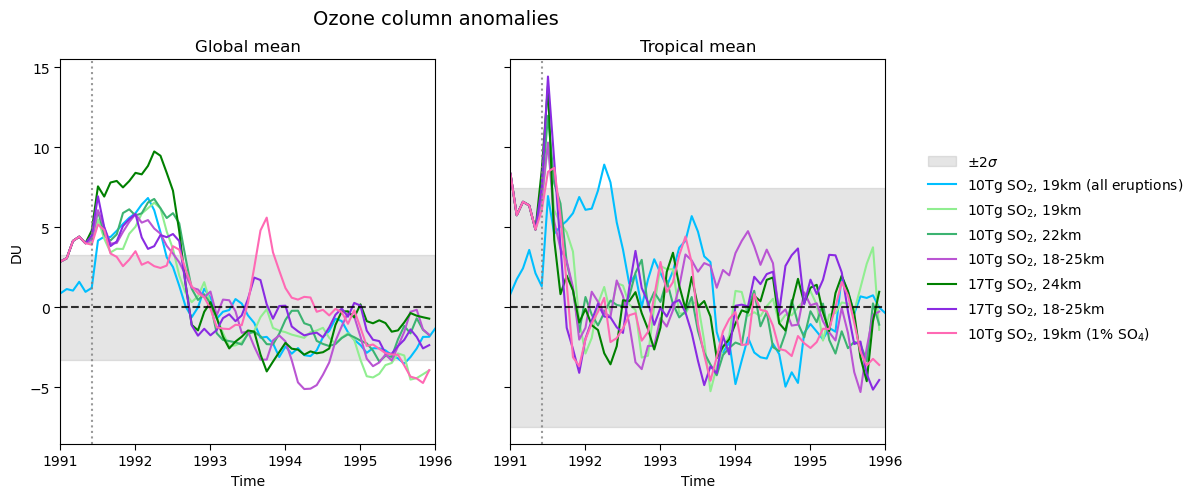

In [11]:
t_19     = [t.year + (t.month-1)/12 for t in o3_anom.time.values]
t_19_c   = [t.year + (t.month-1)/12 for t in o3_19_c_anom.time.values]
t_22     = [t.year + (t.month-1)/12 for t in o3_22_anom.time.values]
t_1825   = [t.year + (t.month-1)/12 for t in o3_1825_anom.time.values]
t_24     = [t.year + (t.month-1)/12 for t in o3_24_anom.time.values]
t_1825_17tg   = [t.year + (t.month-1)/12 for t in o3_1825_17tg_anom.time.values]
t_1tg    = [t.year + (t.month-1)/12 for t in o3_1tg_anom.time.values]
t_1pr    = [t.year + (t.month-1)/12 for t in o3_1pr_anom.time.values]
t_60tg   = [t.year + (t.month-1)/12 for t in o3_60tg_anom.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].fill_between(t_19, 
                   - 2 * o3_glob_std, 
                   + 2 * o3_glob_std, 
                   color='gray', alpha=0.2, zorder=0, label="$\pm2\sigma$")
ax[0].plot(t_19, o3_anom, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_22, o3_22_anom, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[0].plot(t_1825, o3_1825_anom, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[0].plot(t_24, o3_24_anom, color = "green", label = "17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg, o3_1825_17tg_anom, color = "blueviolet", label = "17Tg SO$_2$, 18-25km")
#ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_1pr, o3_1pr_anom, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].fill_between(t_19,
                - 2*o3_trop_std, 
                + 2*o3_trop_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[1].plot(t_19, o3_anom_trop, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_22, o3_22_anom_trop, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[1].plot(t_1825, o3_1825_anom_trop, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[1].plot(t_24, o3_24_anom_trop, color = "green", label = "17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg, o3_1825_17tg_anom_trop, color = "blueviolet", label =  "17Tg SO$_2$, 18-25km")
#ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_1pr, o3_1pr_anom_trop, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3028089/3837282967.py:5: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
/tmp/ipykernel_3028089/3837282967.py:16: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")


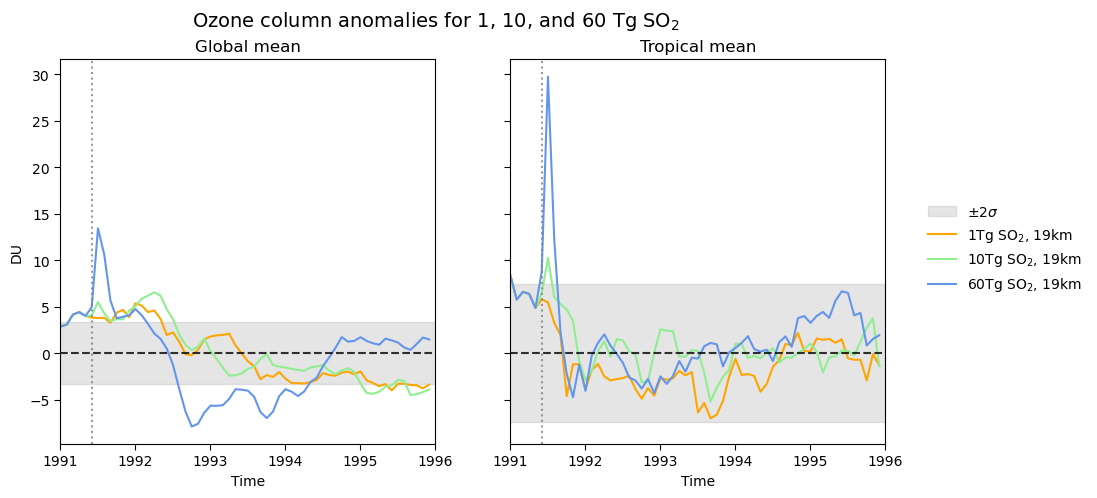

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].fill_between(t_19,
                0 - 2*o3_glob_std, 
                0 + 2*o3_glob_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].fill_between(t_19,
                0 - 2*o3_trop_std, 
                0 + 2*o3_trop_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies for 1, 10, and 60 Tg SO$_2$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [13]:
def polar_cap_mean(ds, weights, lat_min, lat_max):
    return (
        ds["cb_O3"]
        .sel(lat=slice(lat_min, lat_max))
        .weighted(weights.sel(lat=slice(lat_min, lat_max)))
        .mean(dim=["lat", "lon"])
        * DU
    )

def monthly_anomaly_from_base(series, base_monthly, plot_start="1991-01", plot_end="1995-12"):
    anom = series.groupby("time.month") - base_monthly
    return anom.sel(time=slice(plot_start, plot_end))

def season_only(da, season):
    return da.where(da.time.dt.season == season, drop=True)

def time_float(da):
    return [t.year + (t.month - 1) / 12 for t in da.time.values]

In [14]:
# SH baseline, 90S-60S
o3_sh_std_full = polar_cap_mean(cb_O3_19, weighted_lat, -90, -60)
o3_sh_base = o3_sh_std_full.sel(time=slice("1986-01", "1990-12"))
base_sh = o3_sh_base.groupby("time.month").mean("time")

o3_sh_base_anom = o3_sh_base.groupby("time.month") - base_sh
o3_sh_std_son = float(season_only(o3_sh_base_anom, "SON").std().values)


# NH baseline, 60N-90N
o3_nh_std_full = polar_cap_mean(cb_O3_19, weighted_lat, 60, 90)
o3_nh_base = o3_nh_std_full.sel(time=slice("1986-01", "1990-12"))
base_nh = o3_nh_base.groupby("time.month").mean("time")

o3_nh_base_anom = o3_nh_base.groupby("time.month") - base_nh
o3_nh_std_mam = float(season_only(o3_nh_base_anom, "MAM").std().values)

In [15]:
# SH anomalies
o3_19_sh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_19, weighted_lat, -90, -60), base_sh)
o3_19_c_sh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_19_c, weighted_lat_19_c, -90, -60), base_sh)
o3_22_sh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_22, weighted_lat_22, -90, -60), base_sh)
o3_1825_sh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1825, weighted_lat_1825, -90, -60), base_sh)
o3_24_sh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_24, weighted_lat_24, -90, -60), base_sh)
o3_1825_17_sh = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1825_17tg, weighted_lat_1825_17tg, -90, -60), base_sh)
o3_1pr_sh     = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1pr, weighted_lat_1pr, -90, -60), base_sh)
o3_1tg_sh     = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1tg, weighted_lat_1tg, -90, -60), base_sh)
o3_60tg_sh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_60tg, weighted_lat_60tg, -90, -60), base_sh)

# NH anomalies
o3_19_nh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_19, weighted_lat, 60, 90), base_nh)
o3_19_c_nh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_19_c, weighted_lat_19_c, 60, 90), base_nh)
o3_22_nh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_22, weighted_lat_22, 60, 90), base_nh)
o3_1825_nh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1825, weighted_lat_1825, 60, 90), base_nh)
o3_24_nh      = monthly_anomaly_from_base(polar_cap_mean(cb_O3_24, weighted_lat_24, 60, 90), base_nh)
o3_1825_17_nh = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1825_17tg, weighted_lat_1825_17tg, 60, 90), base_nh)
o3_1pr_nh     = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1pr, weighted_lat_1pr, 60, 90), base_nh)
o3_1tg_nh     = monthly_anomaly_from_base(polar_cap_mean(cb_O3_1tg, weighted_lat_1tg, 60, 90), base_nh)
o3_60tg_nh    = monthly_anomaly_from_base(polar_cap_mean(cb_O3_60tg, weighted_lat_60tg, 60, 90), base_nh)

In [16]:
# SH SON
o3_19_sh_son      = season_only(o3_19_sh, "SON")
o3_19_c_sh_son    = season_only(o3_19_c_sh, "SON")
o3_22_sh_son      = season_only(o3_22_sh, "SON")
o3_1825_sh_son    = season_only(o3_1825_sh, "SON")
o3_24_sh_son      = season_only(o3_24_sh, "SON")
o3_1825_17_sh_son = season_only(o3_1825_17_sh, "SON")
o3_1pr_sh_son     = season_only(o3_1pr_sh, "SON")
o3_1tg_sh_son     = season_only(o3_1tg_sh, "SON")
o3_60tg_sh_son    = season_only(o3_60tg_sh, "SON")

# NH MAM
o3_19_nh_mam      = season_only(o3_19_nh, "MAM")
o3_19_c_nh_mam    = season_only(o3_19_c_nh, "MAM")
o3_22_nh_mam      = season_only(o3_22_nh, "MAM")
o3_1825_nh_mam    = season_only(o3_1825_nh, "MAM")
o3_24_nh_mam      = season_only(o3_24_nh, "MAM")
o3_1825_17_nh_mam = season_only(o3_1825_17_nh, "MAM")
o3_1pr_nh_mam     = season_only(o3_1pr_nh, "MAM")
o3_1tg_nh_mam     = season_only(o3_1tg_nh, "MAM")
o3_60tg_nh_mam    = season_only(o3_60tg_nh, "MAM")

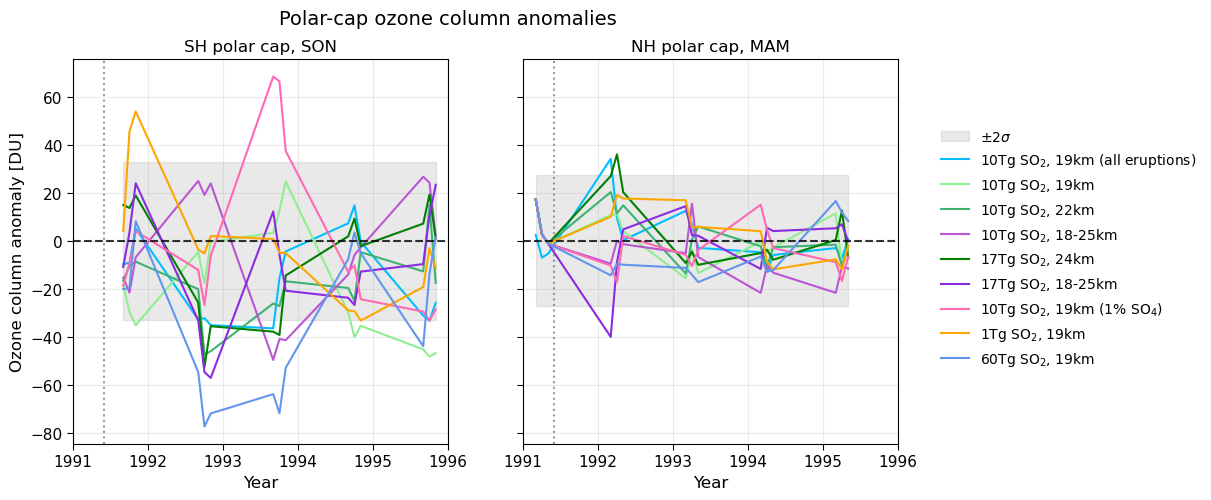

In [17]:
def to_float_time(da):
    return [t.year + (t.month - 1)/12 for t in da.time.values]

# time arrays
t_19_sh        = to_float_time(o3_19_sh_son)
t_19_c_sh      = to_float_time(o3_19_c_sh_son)
t_22_sh        = to_float_time(o3_22_sh_son)
t_1825_sh      = to_float_time(o3_1825_sh_son)
t_24_sh        = to_float_time(o3_24_sh_son)
t_1825_17tg_sh = to_float_time(o3_1825_17_sh_son)
t_1pr_sh       = to_float_time(o3_1pr_sh_son)
t_1tg_sh     = to_float_time(o3_1tg_sh_son)
t_60tg_sh    = to_float_time(o3_60tg_sh_son)

t_19_nh        = to_float_time(o3_19_nh_mam)
t_19_c_nh      = to_float_time(o3_19_c_nh_mam)
t_22_nh        = to_float_time(o3_22_nh_mam)
t_1825_nh      = to_float_time(o3_1825_nh_mam)
t_24_nh        = to_float_time(o3_24_nh_mam)
t_1825_17tg_nh = to_float_time(o3_1825_17_nh_mam)
t_1pr_nh       = to_float_time(o3_1pr_nh_mam)
t_1tg_nh     = to_float_time(o3_1tg_nh_mam)
t_60tg_nh    = to_float_time(o3_60tg_nh_mam)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Left panel: SH polar cap
ax[0].fill_between(
    t_19_sh,
    -2 * o3_sh_std_son,
    +2 * o3_sh_std_son,
    color="gray",
    alpha=0.17,
    zorder=0,
    label=r"$\pm2\sigma$"
)

ax[0].plot(t_19_sh, o3_19_sh_son, color="deepskyblue", label="10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_19_c_sh, o3_19_c_sh_son, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(t_22_sh, o3_22_sh_son, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[0].plot(t_1825_sh, o3_1825_sh_son, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[0].plot(t_24_sh, o3_24_sh_son, color="green", label="17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg_sh, o3_1825_17_sh_son, color="blueviolet", label="17Tg SO$_2$, 18-25km")
ax[0].plot(t_1pr_sh, o3_1pr_sh_son, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
ax[0].plot(t_1tg_sh, o3_1tg_sh_son, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_60tg_sh, o3_60tg_sh_son, color="cornflowerblue", label="60Tg SO$_2$, 19km")

ax[0].set_ylabel("Ozone column anomaly [DU]", fontsize=12)
ax[0].set_xlabel("Year", fontsize=12)
ax[0].set_title("SH polar cap, SON", fontsize=12)

# Right panel: NH polar cap
ax[1].fill_between(
    t_19_nh,
    -2 * o3_nh_std_mam,
    +2 * o3_nh_std_mam,
    color="gray",
    alpha=0.17,
    zorder=0,
    label=r"$\pm2\sigma$"
)

ax[1].plot(t_19_nh, o3_19_nh_mam, color="deepskyblue", label="10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_19_c_nh, o3_19_c_nh_mam, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[1].plot(t_22_nh, o3_22_nh_mam, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[1].plot(t_1825_nh, o3_1825_nh_mam, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[1].plot(t_24_nh, o3_24_nh_mam, color="green", label="17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg_nh, o3_1825_17_nh_mam, color="blueviolet", label="17Tg SO$_2$, 18-25km")
ax[1].plot(t_1pr_nh, o3_1pr_nh_mam, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
ax[1].plot(t_1tg_nh, o3_1tg_nh_mam, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_60tg_nh, o3_60tg_nh_mam, color="cornflowerblue", label="60Tg SO$_2$, 19km")

ax[1].set_xlabel("Year", fontsize=12)
ax[1].set_title("NH polar cap, MAM", fontsize=12)

eruption_float = 1991 + (6 - 1)/12

for a in ax:
    a.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction="out", length=4, labelsize=11)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)
    a.grid(True, alpha=0.25)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Polar-cap ozone column anomalies", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [18]:
def get_total_du(ds, lat_range=None):
    var = "cb_O3"
    data = ds[var].sel(lat=slice(*lat_range)) if lat_range else ds[var]
    weights = np.cos(np.deg2rad(data.lat))
    return data.weighted(weights).mean(dim=["lat", "lon"]) * DU

o3 = get_total_du(cb_O3_19)
o3_19_c = get_total_du(cb_O3_19_c)
o3_22 = get_total_du(cb_O3_22)
o3_1825 = get_total_du(cb_O3_1825)
o3_24 = get_total_du(cb_O3_24)
o3_1825_17tg = get_total_du(cb_O3_1825_17tg)
o3_1pr = get_total_du(cb_O3_1pr)
o3_1tg = get_total_du(cb_O3_1tg)
o3_60tg = get_total_du(cb_O3_60tg)

o3_trop = get_total_du(cb_O3_19, lat_range=(-20, 20))
o3_19_c_trop = get_total_du(cb_O3_19_c, lat_range=(-20, 20))
o3_22_trop = get_total_du(cb_O3_22, lat_range=(-20, 20))
o3_1825_trop = get_total_du(cb_O3_1825, lat_range=(-20, 20))
o3_24_trop = get_total_du(cb_O3_24, lat_range=(-20, 20))
o3_1825_17tg_trop = get_total_du(cb_O3_1825_17tg, lat_range=(-20, 20))
o3_1pr_trop = get_total_du(cb_O3_1pr, lat_range=(-20, 20))
o3_1tg_trop = get_total_du(cb_O3_1tg, lat_range=(-20,20))
o3_60tg_trop = get_total_du(cb_O3_60tg, lat_range=(-20,20))

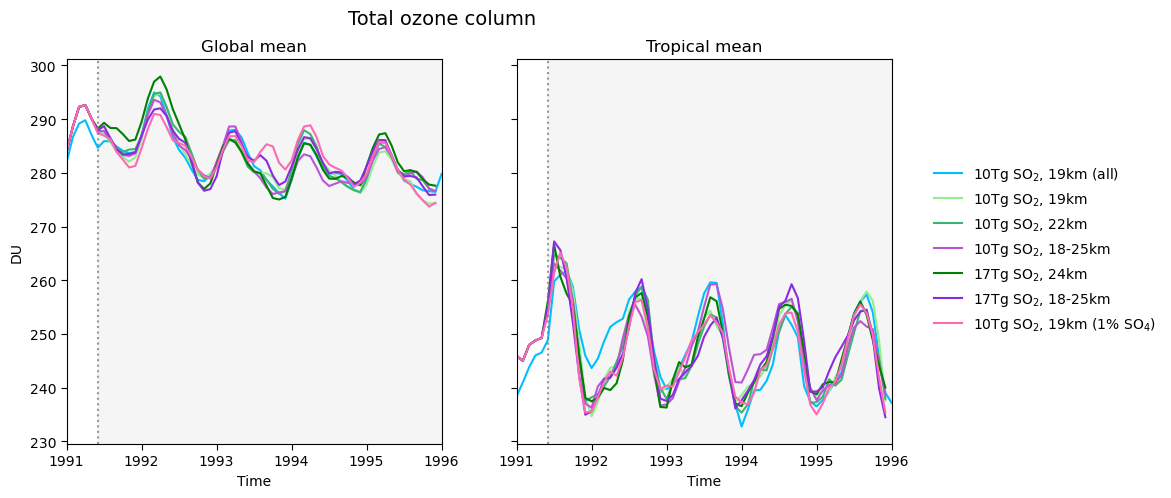

In [19]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
def to_float(x):
    return [t.year + (t.month-1)/12 for t in x.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(o3), o3, color="deepskyblue", label="10Tg SO$_2$, 19km (all)")
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_22), o3_22, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[0].plot(to_float(o3_1825), o3_1825, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[0].plot(to_float(o3_24), o3_24, color="green", label="17Tg SO$_2$, 24km")
ax[0].plot(to_float(o3_1825_17tg), o3_1825_17tg, color="blueviolet", label="17Tg SO$_2$, 18-25km")
#ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1pr), o3_1pr, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_ylabel("DU")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

ax[1].plot(to_float(o3_trop), o3_trop, color="deepskyblue")
ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_22_trop), o3_22_trop, color="mediumseagreen")
ax[1].plot(to_float(o3_1825_trop), o3_1825_trop, color="mediumorchid")
ax[1].plot(to_float(o3_24_trop), o3_24_trop, color="green")
ax[1].plot(to_float(o3_1825_17tg_trop), o3_1825_17tg_trop, color="blueviolet")
#ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_1pr_trop), o3_1pr_trop, color="hotpink")
#ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

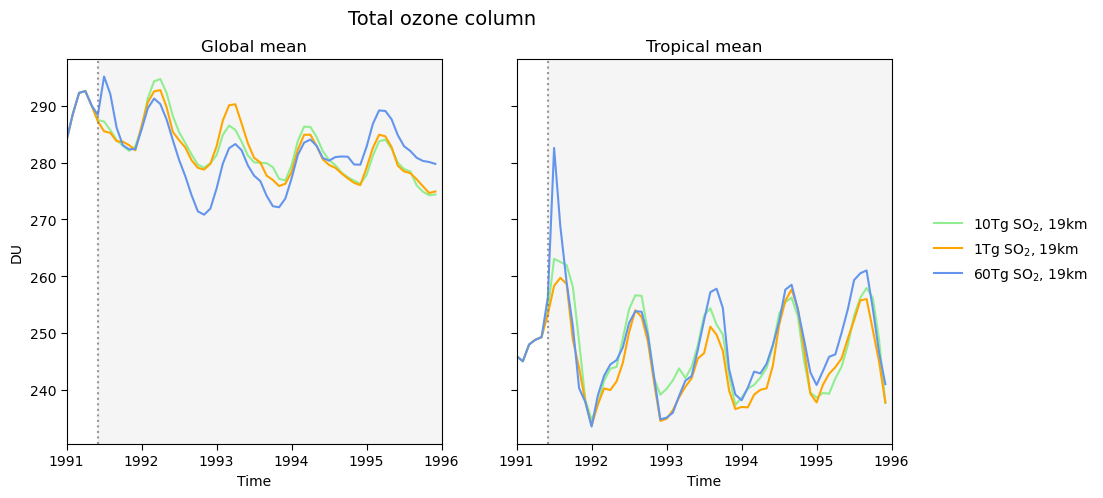

In [20]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [21]:
aod_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/AOD_VIS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in aod_19['time'].values])
aod_19 = aod_19.assign_coords(time=shifted_time_19)
aod_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/AOD_VIS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in aod_19_c['time'].values])
aod_19_c = aod_19_c.assign_coords(time=shifted_time_19_c)
aod_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in aod_22['time'].values])
aod_22 = aod_22.assign_coords(time=shifted_time_22)
aod_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in aod_24['time'].values])
aod_24 = aod_24.assign_coords(time=shifted_time_24)
aod_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in aod_1825_17tg['time'].values])
aod_1825_17tg = aod_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
aod_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in aod_1825['time'].values])
aod_1825 = aod_1825.assign_coords(time=shifted_time_1825)
aod_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/AOD_VIS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in aod_1tg['time'].values])
aod_1tg = aod_1tg.assign_coords(time=shifted_time_1tg)
aod_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/AOD_VIS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in aod_1pr['time'].values])
aod_1pr = aod_1pr.assign_coords(time=shifted_time_1pr)
aod_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/AOD_VIS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in aod_60tg['time'].values])
aod_60tg = aod_60tg.assign_coords(time=shifted_time_60tg)

In [22]:
day_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/DAYFOC_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in day_19['time'].values])
day_19 = day_19.assign_coords(time=shifted_time_19)
day_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/DAYFOC_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in day_19_c['time'].values])
day_19_c = day_19_c.assign_coords(time=shifted_time_19_c)
day_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/DAYFOC_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in day_22['time'].values])
day_22 = day_22.assign_coords(time=shifted_time_22)
day_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/DAYFOC_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in day_24['time'].values])
day_24 = day_24.assign_coords(time=shifted_time_24)
day_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in day_1825_17tg['time'].values])
day_1825_17tg = day_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
day_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in day_1825['time'].values])
day_1825 = day_1825.assign_coords(time=shifted_time_1825)
day_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/DAYFOC_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in day_1tg['time'].values])
day_1tg = day_1tg.assign_coords(time=shifted_time_1tg)
day_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/DAYFOC_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in day_1pr['time'].values])
day_1pr = day_1pr.assign_coords(time=shifted_time_1pr)
day_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/DAYFOC_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in day_60tg['time'].values])
day_60tg = day_60tg.assign_coords(time=shifted_time_60tg)

In [23]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = aod_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = day_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()
ts_aod_22 = aod_22[aod500].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = day_22[daylight].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22 = ts_aod_22 / daylight_monthly_22
ts_aod_19_c = aod_19_c[aod500].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = day_19_c[daylight].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c = ts_aod_19_c / daylight_monthly_19_c
ts_aod_24 = aod_24[aod500].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24= day_24[daylight].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24 = ts_aod_24 / daylight_monthly_24
ts_aod_1825 =aod_1825[aod500].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825= day_1825[daylight].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825 = ts_aod_1825 / daylight_monthly_1825
ts_aod_1825_17tg = aod_1825_17tg[aod500].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg= day_1825_17tg[daylight].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg = ts_aod_1825_17tg / daylight_monthly_1825_17tg
ts_aod_1tg = aod_1tg[aod500].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg= day_1tg[daylight].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg = ts_aod_1tg / daylight_monthly_1tg
ts_aod_1pr = aod_1pr[aod500].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr= day_1pr[daylight].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr = ts_aod_1pr / daylight_monthly_1pr
ts_aod_60tg = aod_60tg[aod500].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg= day_60tg[daylight].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg = ts_aod_60tg / daylight_monthly_60tg

In [24]:
pre_eruption = ts_aod.sel(time=slice("1986-01", "1990-12"))
base = pre_eruption.groupby("time.month").mean("time")
anomalies = pre_eruption.groupby("time.month") - base
aod_std = anomalies.std(dim="time")
aod_mean = anomalies.mean(dim="time")

aod_anom = ts_aod.groupby("time.month") - base
aod_anom_22 = ts_aod_22.groupby("time.month") - base
aod_anom_19_c = ts_aod_19_c.groupby("time.month") - base
aod_anom_24 = ts_aod_24.groupby("time.month") - base
aod_anom_1825 = ts_aod_1825.groupby("time.month") - base
aod_anom_1825_17tg = ts_aod_1825_17tg.groupby("time.month") - base
aod_anom_1tg = ts_aod_1tg.groupby("time.month") - base
aod_anom_1pr = ts_aod_1pr.groupby("time.month") - base
aod_anom_60tg = ts_aod_60tg.groupby("time.month") - base
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))
aod_smooth = aod_Pinatubo.rolling(time=1, center=True).mean()

In [25]:
def plot_aod_vs_ozone(aod_series, ozone_series, title):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color_aod = 'tab:red'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Stratospheric AOD', color=color_aod, fontsize=12)
    ax1.plot(aod_series.time, aod_series, color=color_aod, linewidth=2, label='AOD')
    ax1.tick_params(axis='y', labelcolor=color_aod)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    color_o3 = 'tab:blue'
    ax2.set_ylabel('Global Ozone Anomaly [DU]', color=color_o3, fontsize=12)
    ax2.plot(ozone_series.time, ozone_series, color=color_o3, linewidth=2, label='Ozon')
    ax2.tick_params(axis='y', labelcolor=color_o3)

    plt.title(title, fontsize=14)
    fig.tight_layout()
    return fig, ax1, ax2


In [26]:
ozone_series = [o3_anom, o3_19_c_anom, o3_22_anom, o3_24_anom, o3_1825_anom, o3_1825_17tg_anom,
                o3_1pr_anom, o3_1tg_anom, o3_60tg_anom]

aod_series = [aod_Pinatubo, aod_anom_19_c, aod_anom_22, aod_anom_24, aod_anom_1825, aod_anom_1825_17tg,
              aod_anom_1pr, aod_anom_1tg, aod_anom_60tg]

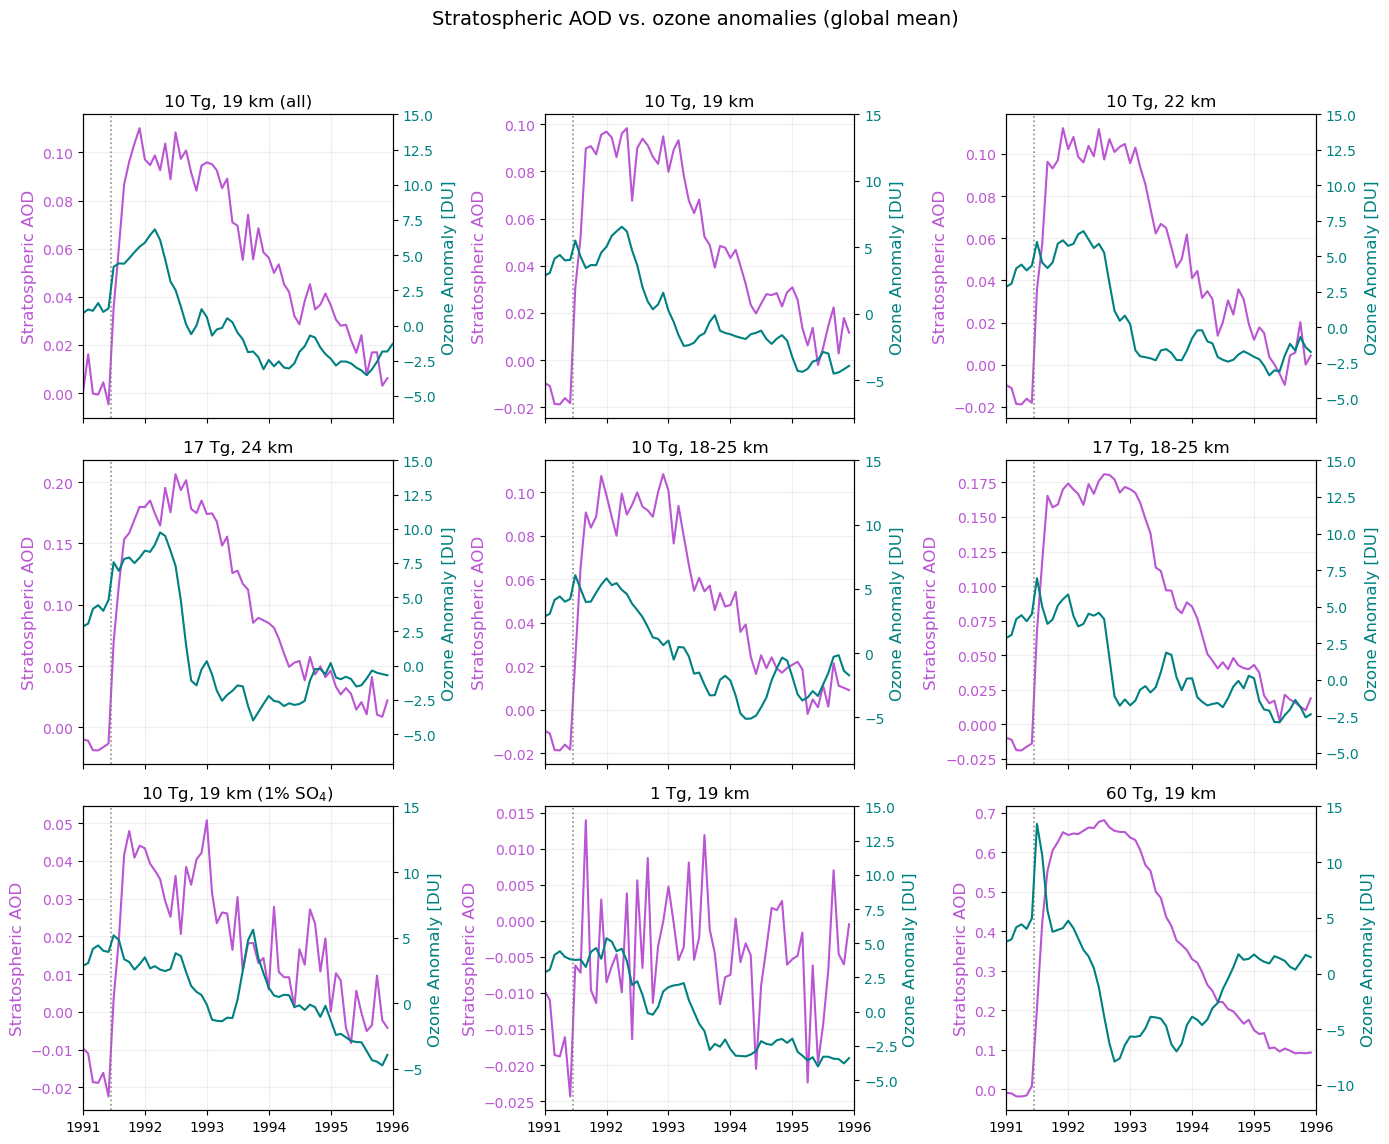

In [27]:
titles = ["10 Tg, 19 km (all)",
          "10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km",
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO$_4$)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]
eruption_date = cftime.DatetimeNoLeap(1991, 6, 15)

fig, axs = plt.subplots(3, 3, figsize=(14, 12), sharex=True)
plt.subplots_adjust(hspace=0.3, wspace=0.4)

for ax, o3_s, aod_s, title in zip(axs.flat, ozone_series, aod_series, titles):
    dims_to_reduce_o3 = [d for d in ['lat', 'lon'] if d in o3_s.dims]
    if dims_to_reduce_o3:
        o3_1d = o3_s.mean(dim=dims_to_reduce_o3)
    else:
        o3_1d = o3_s

    dims_to_reduce_aod = [d for d in ['lat', 'lon'] if d in aod_s.dims]
    if dims_to_reduce_aod:
        aod_1d = aod_s.mean(dim=dims_to_reduce_aod)
    else:
        aod_1d = aod_s

    ax.plot(aod_1d.time, aod_1d, color='mediumorchid', linewidth=1.5, label='AOD')
    ax.set_ylabel('Stratospheric AOD', color='mediumorchid', fontsize=12)
    ax.tick_params(axis='y', labelcolor='mediumorchid')
    ax.set_title(title, fontsize=12)
    
    ax2 = ax.twinx()
    ax2.plot(o3_1d.time, o3_1d, color='teal', linewidth=1.5, label='Ozon')
    ax2.set_ylabel('Ozone Anomaly [DU]', color='teal', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='teal')
    
    years = [1991, 1992, 1993, 1994, 1995, 1996]
    ax.set_xticks([cftime.DatetimeNoLeap(y, 1, 1) for y in years])
    ax.set_xticklabels([str(y) for y in years])

    ymin = float(o3_1d.min())
    ax2.set_ylim(ymin * 1.3 - 2, 15) 
    ax.axvline(eruption_date, color="gray", ls=":", alpha=0.9, lw=1.2)
    ax.grid(alpha=0.2)
    ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

fig.suptitle("Stratospheric AOD vs. ozone anomalies (global mean)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [28]:
o3_cb = cb_O3_19[cb_o3]
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3_cb.groupby("time.month") - base

o3_zoom= o3_anom.sel(time=slice('1991-01-01', '1994-01-01'))
o3_mean = o3_zoom.mean(dim="lon") * DU
lat_o3 = o3_mean["lat"]
time_o3 = o3_zoom["time"].values

In [29]:
o3_cb = cb_O3_19[cb_o3].mean(dim="lon")
baseline = o3_cb.sel(time=slice("1986-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [30]:
o3_base_zonal = cb_O3_19["cb_O3"].sel(time=slice("1986-01-01", "1990-12-31")).mean(dim="lon")

base = o3_base_zonal.groupby("time.month").mean("time")
base_std = o3_base_zonal.groupby("time.month").std("time")

In [31]:
def plot_o3_panel(
    ds,
    base,
    base_std,
    ax,
    title,
    plot_period=("1991-01-01", "1995-12-31")
):
    o3_zonal = ds["cb_O3"].mean(dim="lon")

    o3_anom = (o3_zonal.groupby("time.month") - base) / base * 100

    sigma2_pct = (2 * base_std / base) * 100

    sig_field = np.abs(o3_anom).groupby("time.month") - sigma2_pct

    if "month" in o3_anom.dims:
        o3_anom = o3_anom.mean("month").squeeze()
    else:
        o3_anom = o3_anom.squeeze()

    if "month" in sig_field.dims:
        sig_field = sig_field.mean("month").squeeze()
    else:
        sig_field = sig_field.squeeze()

    o3_sel = o3_anom.sel(time=slice(*plot_period))
    sig_sel = sig_field.sel(time=slice(*plot_period))

    vmin, vmax = -10, 10
    levels = np.linspace(vmin, vmax, 21)
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

    im = ax.contourf(
        o3_sel.time.values,
        o3_sel.lat.values,
        o3_sel.T.values,
        levels=levels,
        cmap="coolwarm",
        norm=norm,
        extend="both"
    )

    ax.contour(
        sig_sel.time.values,
        sig_sel.lat.values,
        sig_sel.T.values,
        levels=[0],
        colors="gray",
        alpha = 0.8,
        linewidths=1.0,
        linestyles="--"
    )

    ax.plot(
        cftime.DatetimeNoLeap(1991, 6, 15),
        0,
        marker="^",
        color="red",
        markeredgecolor="black",
        markersize=10,
        zorder=5
    )

    years = [1991, 1992, 1993, 1994, 1995, 1996]
    tick_dates = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]

    ax.set_xticks(tick_dates)
    ax.set_xticklabels([str(y) for y in years])
    ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(direction="out", length=4)

    ss = ax.get_subplotspec()

    if ss.is_first_row():
        ax.tick_params(axis="x", top=True, labeltop=False, bottom=True, labelbottom=False)

    else:
        ax.tick_params(axis="x", top=False, labeltop=False, bottom=True, labelbottom=True)

    if ss.is_first_col():
        ax.set_yticks([-90, -60, -30, 0, 30, 60, 90])
        ax.set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])
        ax.set_ylabel("Latitude", fontsize=12)
    else:
        ax.set_yticklabels([])

    ax.set_title(title, fontsize=12)

    return im

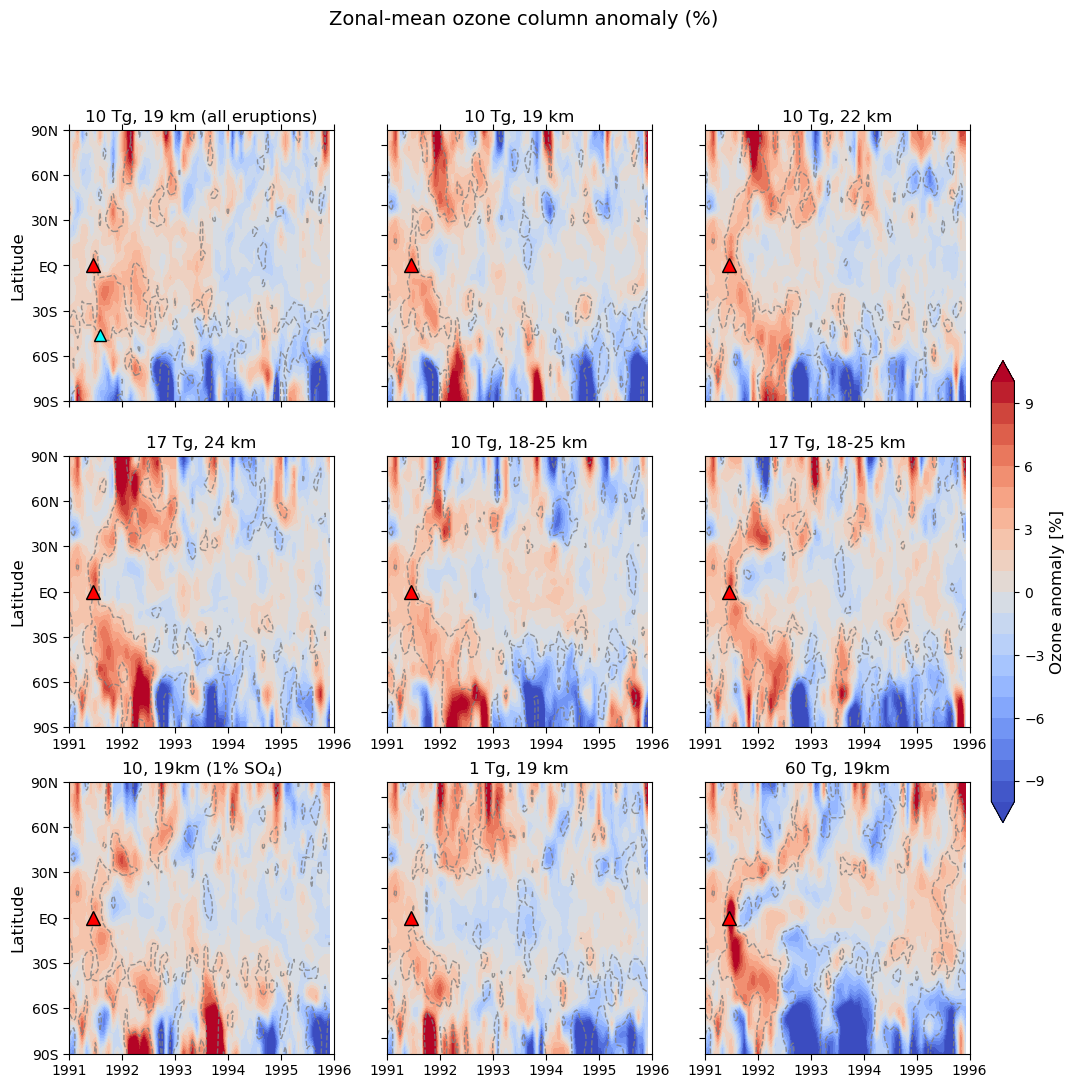

In [32]:
datasets = [cb_O3_19, cb_O3_19_c, cb_O3_22, cb_O3_24, cb_O3_1825, cb_O3_1825_17tg, cb_O3_1pr, cb_O3_1tg, cb_O3_60tg]
titles = [
    "10 Tg, 19 km (all eruptions)",
    "10 Tg, 19 km",
    "10 Tg, 22 km",
    "17 Tg, 24 km",
    "10 Tg, 18-25 km",
    "17 Tg, 18-25 km",
    "10, 19km (1% SO$_4$)",
    "1 Tg, 19 km",
    "60 Tg, 19km"
]

fig, axs = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=False)

for ax, ds, title in zip(axs.flat, datasets, titles):
    im = plot_o3_panel(
        ds,
        base=base,
        base_std=base_std,
        ax=ax,
        title=title
    )

axs[0, 0].plot(
    cftime.DatetimeNoLeap(1991, 8, 1),
    -45.92,
    marker="^",
    color="cyan",
    markeredgecolor="k",
    markersize=8,
    zorder=10,
    clip_on=False
)

cbar = fig.colorbar(
    im,
    ax=axs,
    location="right",
    shrink=0.5,
    pad=0.02,
    extend="both"
)
cbar.set_label("Ozone anomaly [%]", fontsize=12)

plt.suptitle("Zonal-mean ozone column anomaly (%)", fontsize=14, x=0.45)

plt.show()

In [33]:
O3_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/O3_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in O3_19['time'].values])
O3_19 = O3_19.assign_coords(time=shifted_time_19)
O3_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/O3_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in O3_19_c['time'].values])
O3_19_c = O3_19_c.assign_coords(time=shifted_time_19_c)
O3_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/O3_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in O3_22['time'].values])
O3_22 = O3_22.assign_coords(time=shifted_time_22)
O3_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/O3_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in O3_24['time'].values])
O3_24 = O3_24.assign_coords(time=shifted_time_24)
O3_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/O3_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in O3_1825_17tg['time'].values])
O3_1825_17tg = O3_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
O3_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/O3_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in O3_1825['time'].values])
O3_1825 = O3_1825.assign_coords(time=shifted_time_1825)
O3_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/O3_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in O3_1tg['time'].values])
O3_1tg = O3_1tg.assign_coords(time=shifted_time_1tg)
O3_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/O3_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in O3_1pr['time'].values])
O3_1pr = O3_1pr.assign_coords(time=shifted_time_1pr)
O3_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/O3_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in O3_60tg['time'].values])
O3_60tg = O3_60tg.assign_coords(time=shifted_time_60tg)

In [34]:
o3 = O3_19["O3"].mean(dim="lon")
baseline = o3.sel(time=slice("1986-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [35]:
O3_19.lev

<xarray.DataArray 'lev' (lev: 32)> Size: 256B
array([  3.643466,   7.59482 ,  14.356632,  24.61222 ,  35.92325 ,  43.19375 ,
        51.677499,  61.520498,  73.750958,  87.82123 , 103.317127, 121.547241,
       142.994039, 168.22508 , 197.908087, 232.828619, 273.910817, 322.241902,
       379.100904, 445.992574, 524.687175, 609.778695, 691.38943 , 763.404481,
       820.858369, 859.534767, 887.020249, 912.644547, 936.198398, 957.48548 ,
       976.325407, 992.556095])
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Attributes:
    long_name:      hybrid level at midpoints (1000*(A+B))
    units:          hPa
    positive:       down
    standard_name:  atmosphere_hybrid_sigma_pressure_coordinate
    formula_terms:  a: hyam b: hybm p0: P0 ps: PS

In [36]:
def plot_o3_lat_time_final(
    ds,
    base_clim,
    base_std,
    title,
    ax,
    lev=70,
    vmin=-25,
    vmax=25
):
    o3_zonal = ds["O3"].mean(dim="lon")

    o3_slice = o3_zonal.sel(lev=lev, method="nearest")
    base_slice = base_clim.sel(lev=lev, method="nearest")
    std_slice = base_std.sel(lev=lev, method="nearest")

    o3_anom = (o3_slice.groupby("time.month") - base_slice) / base_slice * 100

    sigma2_pct = (2 * std_slice / base_slice) * 100

    sig_field = np.abs(o3_anom).groupby("time.month") - sigma2_pct

    if "month" in o3_anom.dims:
        o3_anom = o3_anom.mean("month").squeeze()
    else:
        o3_anom = o3_anom.squeeze()

    if "month" in sig_field.dims:
        sig_field = sig_field.mean("month").squeeze()
    else:
        sig_field = sig_field.squeeze()

    o3_plot = o3_anom.sel(time=slice("1991-01-01", "1996-01-01"))
    sig_plot = sig_field.sel(time=slice("1991-01-01", "1996-01-01"))

    times = o3_plot.time.values
    lats = o3_plot.lat.values
    data = o3_plot.T.values
    sig_data = sig_plot.T.values

    levels = np.linspace(vmin, vmax, 21)
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

    im = ax.contourf(
        times,
        lats,
        data,
        levels=levels,
        cmap="coolwarm",
        norm=norm,
        extend="both"
    )

    ax.contour(
        times,
        lats,
        sig_data,
        levels=[0],
        colors="gray",
        alpha=0.8,
        linewidths=1.0,
        linestyles="--"
    )

    ax.plot(
        cftime.DatetimeNoLeap(1991, 6, 15),
        15,
        marker="^",
        color="red",
        markeredgecolor="black",
        markersize=10,
        zorder=10
    )

    years = [1991, 1992, 1993, 1994, 1995, 1996]
    tick_dates = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
    ax.set_xticks(tick_dates)
    ax.set_xticklabels([str(y) for y in years])

    ss = ax.get_subplotspec()

    if ss.is_first_row():
        ax.tick_params(axis="x", top=True, labeltop=False, bottom=True, labelbottom=False)
    else:
        ax.tick_params(axis="x", top=False, labeltop=False, bottom=True, labelbottom=True)

    if ss.is_first_col():
        ax.set_yticks([-90, -60, -30, 0, 30, 60, 90])
        ax.set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])
        ax.set_ylabel("Latitude", fontsize=12)
    else:
        ax.set_yticklabels([])

    lev_used = float(o3_slice.lev.values)
    ax.set_title(f"{title}", fontsize=12)

    return im

In [37]:
o3_base_zonal = (
    O3_19["O3"]
    .sel(time=slice("1986-01-01", "1990-12-31"))
    .mean(dim="lon")
)

base_clim = o3_base_zonal.groupby("time.month").mean("time")
base_std = o3_base_zonal.groupby("time.month").std("time")

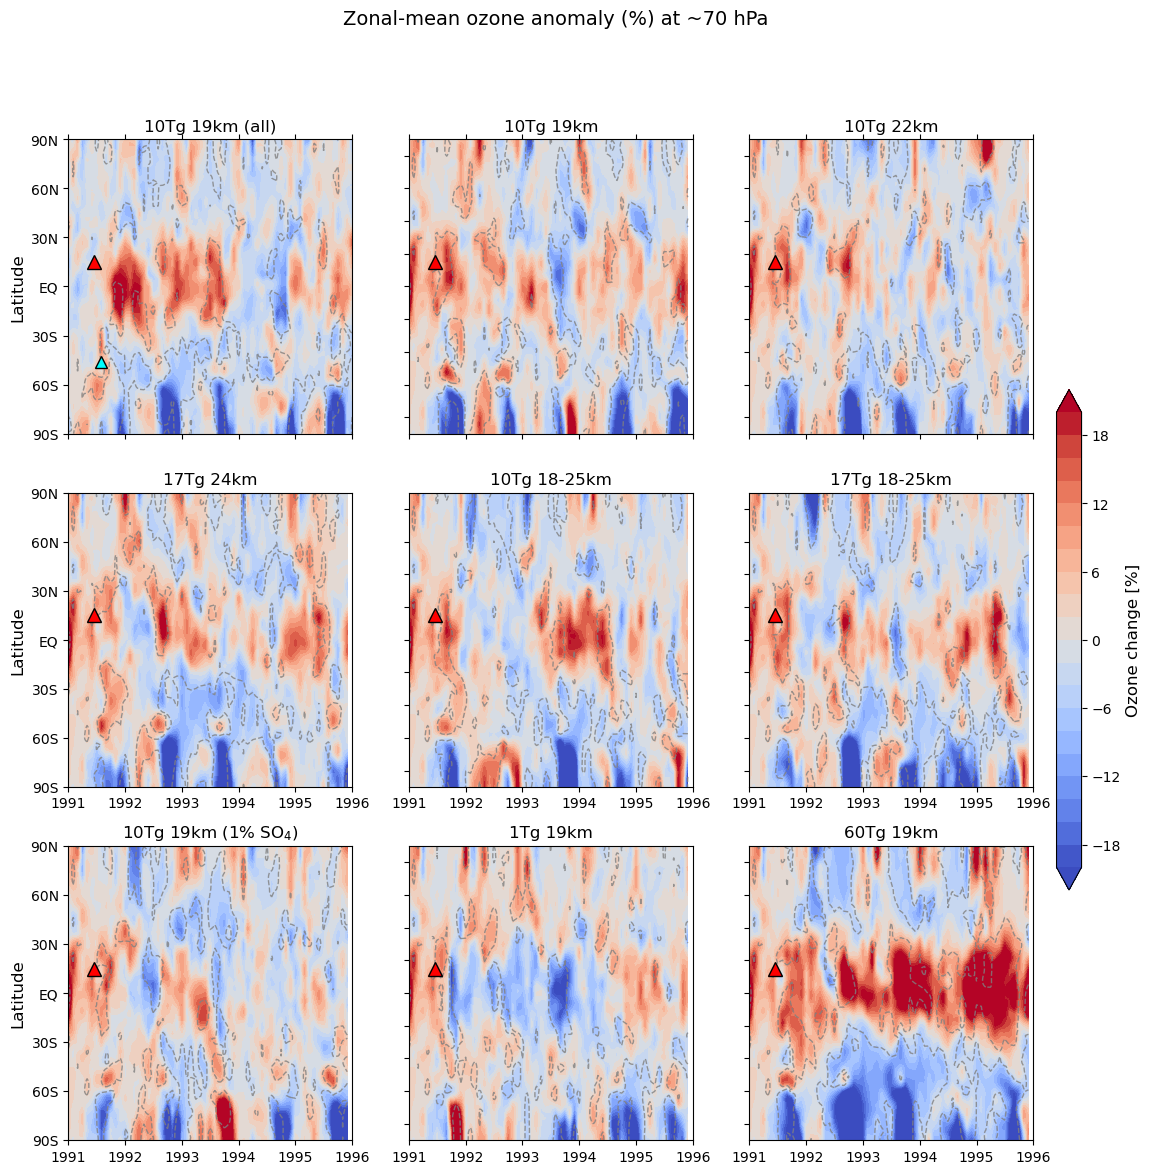

In [38]:
datasets = [O3_19, O3_19_c, O3_22, O3_24, O3_1825, O3_1825_17tg, O3_1pr, O3_1tg, O3_60tg]
titles = [
    "10Tg 19km (all)", "10Tg 19km", "10Tg 22km",
    "17Tg 24km", "10Tg 18-25km", "17Tg 18-25km",
    "10Tg 19km (1% SO$_4$)", "1Tg 19km", "60Tg 19km"
]

fig, axs = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=False)

for ax, ds, title in zip(axs.flat, datasets, titles):
    im = plot_o3_lat_time_final(
        ds=ds,
        base_clim=base_clim,
        base_std=base_std,
        title=title,
        ax=ax,
        lev=70,
        vmin=-20,
        vmax=20
    )

axs[0, 0].plot(
    cftime.DatetimeNoLeap(1991, 8, 1),
    -45.92,
    marker="^",
    color="cyan",
    markeredgecolor="k",
    markersize=8,
    zorder=10,
    clip_on=False
)

cbar = fig.colorbar(im, ax=axs, location="right", shrink=0.5, pad=0.02, extend="both")
cbar.set_label("Ozone change [%]", fontsize=12)

fig.suptitle("Zonal-mean ozone anomaly (%) at ~70 hPa", fontsize=14, x=0.45)
plt.show()

In [39]:
# Global
o3_glob_lev = O3_19["O3"].sel(lev=30, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
base_global = o3_glob_lev.sel(time=slice("1986", "1990")).groupby("time.month").mean()

# Tropics
o3_trop_lev_s = O3_19["O3"].sel(lev=30,method="nearest")
o3_trop_lev_s = o3_trop_lev_s.sel(lat=slice(-20,20)).weighted(weighted_lat.sel(lat=slice(-20,20))).mean(dim=["lat", "lon"])
base_trop = o3_trop_lev_s.sel(time=slice("1986", "1990")).groupby("time.month").mean()

In [40]:
def calc_anomaly_lev(ds, weights, baseline_obj, lev=30, lat_range=None):
    var = "O3"
    data_lev = ds[var].sel(lev=lev, method="nearest").sel(time=slice("1991", "1996")).squeeze()
    
    if lat_range:
        data = data_lev.sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = data_lev
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"])
    
    anom = (mean_ts.groupby("time.month") - baseline_obj) / baseline_obj * 100

    if 'month' in anom.dims:
        anom = anom.mean(dim='month')
        
    return anom

In [41]:
o3_lev = calc_anomaly_lev(O3_19, weighted_lat, base_global)
o3_19_c_lev = calc_anomaly_lev(O3_19_c, weighted_lat_19_c, base_global)
o3_22_lev = calc_anomaly_lev(O3_22, weighted_lat_22, base_global)
o3_1825_lev = calc_anomaly_lev(O3_1825, weighted_lat_1825, base_global)
o3_24_lev = calc_anomaly_lev(O3_24, weighted_lat_24, base_global)
o3_1825_17tg_lev = calc_anomaly_lev(O3_1825_17tg, weighted_lat_1825_17tg, base_global)
o3_1pr_lev = calc_anomaly_lev(O3_1pr, weighted_lat_1pr, base_global)
o3_1tg_lev = calc_anomaly_lev(O3_1tg, weighted_lat_1tg, base_global)
o3_60tg_lev = calc_anomaly_lev(O3_60tg, weighted_lat_60tg, base_global)

o3_trop_lev = calc_anomaly_lev(O3_19, weighted_lat, base_trop, lat_range=(-20, 20))
o3_19_c_trop_lev = calc_anomaly_lev(O3_19_c, weighted_lat_19_c, base_trop, lat_range=(-20, 20))
o3_22_trop_lev = calc_anomaly_lev(O3_22, weighted_lat_22, base_trop, lat_range=(-20, 20))
o3_1825_trop_lev = calc_anomaly_lev(O3_1825, weighted_lat_1825, base_trop, lat_range=(-20, 20))
o3_24_trop_lev = calc_anomaly_lev(O3_24, weighted_lat_24, base_trop, lat_range=(-20, 20))
o3_1825_17tg_trop_lev = calc_anomaly_lev(O3_1825_17tg, weighted_lat_1825_17tg, base_trop, lat_range=(-20, 20))
o3_1pr_trop_lev = calc_anomaly_lev(O3_1pr, weighted_lat_1pr, base_trop, lat_range=(-20, 20))
o3_1tg_trop_lev = calc_anomaly_lev(O3_1tg, weighted_lat_1tg, base_trop, lat_range=(-20,20))
o3_60tg_trop_lev = calc_anomaly_lev(O3_60tg, weighted_lat_60tg, base_trop, lat_range=(-20,20))

In [42]:
glob_86_90 = o3_glob_lev.sel(time=slice("1986", "1990")).values
base_glob_val = base_global.values

diff_glob = glob_86_90 - np.tile(base_glob_val, 5)

o3_glob_std = (np.std(diff_glob) / np.mean(base_glob_val)) * 100

In [43]:
trop_86_90 = o3_trop_lev_s.sel(time=slice("1986", "1990")).values
base_trop_val = base_trop.values

diff_trop = trop_86_90 - np.tile(base_trop_val, 5)

o3_trop_std = (np.std(diff_trop) / np.mean(base_trop_val)) * 100

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3028089/1961971603.py:17: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
/tmp/ipykernel_3028089/1961971603.py:33: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")


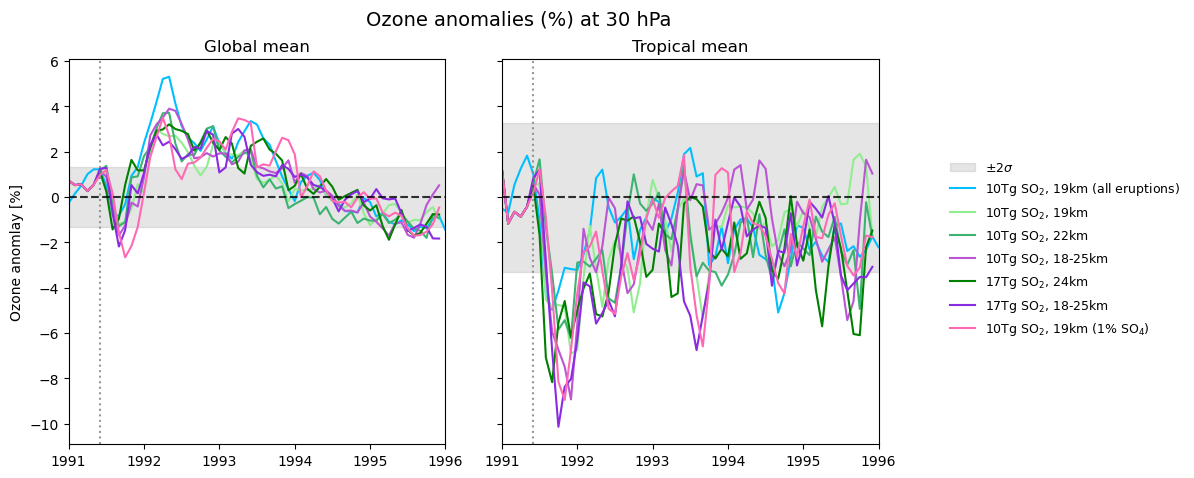

In [44]:
plt.close('all')

t_19 = [t.year + (t.month-1)/12 for t in o3_lev.time.values]
t_19_c = [t.year + (t.month-1)/12 for t in o3_19_c_lev.time.values]
t_22 = [t.year + (t.month-1)/12 for t in o3_22_lev.time.values]
t_1825 = [t.year + (t.month-1)/12 for t in o3_1825_lev.time.values]
t_24 = [t.year + (t.month-1)/12 for t in o3_24_lev.time.values]
t_1825_17tg = [t.year + (t.month-1)/12 for t in o3_1825_17tg_lev.time.values]
t_1tg = [t.year + (t.month-1)/12 for t in o3_1tg_lev.time.values]
t_1pr = [t.year + (t.month-1)/12 for t in o3_1pr_lev.time.values]
t_60tg = [t.year + (t.month-1)/12 for t in o3_60tg_lev.time.values]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].fill_between(t_19,
                0 - 2*o3_glob_std, 
                0 + 2*o3_glob_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[0].plot(t_19, o3_lev, color="deepskyblue", label="10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_19_c, o3_19_c_lev, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(t_22, o3_22_lev, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[0].plot(t_1825, o3_1825_lev, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[0].plot(t_24, o3_24_lev, color="green", label="17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg, o3_1825_17tg_lev, color="blueviolet", label="17Tg SO$_2$, 18-25km")
ax[0].plot(t_1pr, o3_1pr_lev, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")

ax[0].set_xlabel("")
ax[0].set_ylabel("Ozone anomlay [%]") 
ax[0].set_title("Global mean", fontsize=12)

ax[1].fill_between(t_19,
                0 - 2*o3_trop_std, 
                0 + 2*o3_trop_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[1].plot(t_19, o3_trop_lev, color="deepskyblue", label="10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_19_c, o3_19_c_trop_lev, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[1].plot(t_22, o3_22_trop_lev, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[1].plot(t_1825, o3_1825_trop_lev, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[1].plot(t_24, o3_24_trop_lev, color="green", label="17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg, o3_1825_17tg_trop_lev, color="blueviolet", label="17Tg SO$_2$, 18-25km")
ax[1].plot(t_1pr, o3_1pr_trop_lev, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")

ax[1].set_xlabel("")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for a in ax:
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)

h, l = ax[0].get_legend_handles_labels()
unique_legend = dict(zip(l, h))

fig.legend(
    unique_legend.values(), 
    unique_legend.keys(), 
    loc="center left", 
    bbox_to_anchor=(0.85, 0.5), 
    frameon=False,
    fontsize=9
)

fig.suptitle("Ozone anomalies (%) at 30 hPa", fontsize=14)
plt.subplots_adjust(right=0.80, wspace=0.15) 

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3028089/3492326482.py:17: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
/tmp/ipykernel_3028089/3492326482.py:29: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")


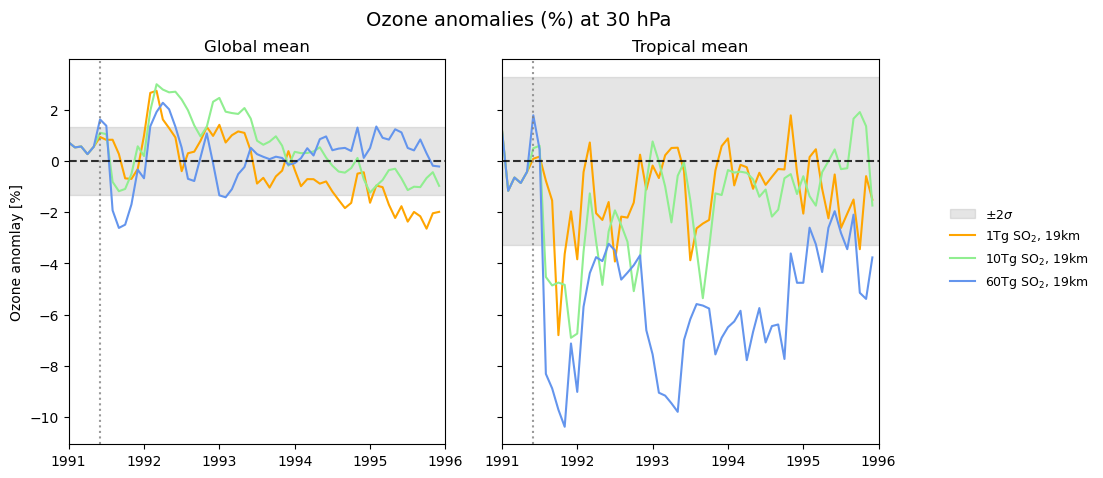

In [45]:
plt.close('all')

t_19 = [t.year + (t.month-1)/12 for t in o3_lev.time.values]
t_19_c = [t.year + (t.month-1)/12 for t in o3_19_c_lev.time.values]
t_22 = [t.year + (t.month-1)/12 for t in o3_22_lev.time.values]
t_1825 = [t.year + (t.month-1)/12 for t in o3_1825_lev.time.values]
t_24 = [t.year + (t.month-1)/12 for t in o3_24_lev.time.values]
t_1825_17tg = [t.year + (t.month-1)/12 for t in o3_1825_17tg_lev.time.values]
t_1tg = [t.year + (t.month-1)/12 for t in o3_1tg_lev.time.values]
t_1pr = [t.year + (t.month-1)/12 for t in o3_1pr_lev.time.values]
t_60tg = [t.year + (t.month-1)/12 for t in o3_60tg_lev.time.values]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].fill_between(t_19,
                0 - 2*o3_glob_std, 
                0 + 2*o3_glob_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[0].plot(t_1tg, o3_1tg_lev, color = "orange", label = "1Tg SO$_2$, 19km")
ax[0].plot(t_19_c, o3_19_c_lev, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(t_60tg, o3_60tg_lev, color = "cornflowerblue", label = "60Tg SO$_2$, 19km")

ax[0].set_xlabel("")
ax[0].set_ylabel("Ozone anomlay [%]") 
ax[0].set_title("Global mean", fontsize=12)

ax[1].fill_between(t_19,
                0 - 2*o3_trop_std, 
                0 + 2*o3_trop_std, 
                color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[1].plot(t_1tg, o3_1tg_trop_lev, color="orange")
ax[1].plot(t_19_c, o3_19_c_trop_lev, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[1].plot(t_60tg, o3_60tg_trop_lev, color="cornflowerblue")

ax[1].set_xlabel("")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for a in ax:
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)

h, l = ax[0].get_legend_handles_labels()
unique_legend = dict(zip(l, h))

fig.legend(
    unique_legend.values(), 
    unique_legend.keys(), 
    loc="center left", 
    bbox_to_anchor=(0.85, 0.5), 
    frameon=False,
    fontsize=9
)

fig.suptitle("Ozone anomalies (%) at 30 hPa", fontsize=14)
plt.subplots_adjust(right=0.80, wspace=0.15) 

plt.show()

In [46]:
def calc_anomaly_lev_ppmv(ds, weights, baseline_obj, lev=70, lat_range=None):
    var = "O3"
    data_lev = ds[var].sel(lev=lev, method="nearest").sel(time=slice("1991", "1996")).squeeze()
    
    if lat_range:
        data = data_lev.sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = data_lev
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"])
    
    anom = (mean_ts.groupby("time.month") - baseline_obj) * 1e6

    if "month" in anom.coords:
        anom = anom.drop_vars("month")
    if "month" in anom.dims:
        anom = anom.mean(dim="month")
        
    return anom

In [47]:
# Global
o3_glob_lev = O3_19["O3"].sel(lev=70, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
base_global = o3_glob_lev.sel(time=slice("1986", "1990")).groupby("time.month").mean()

# Tropics
o3_trop_lev_s = O3_19["O3"].sel(lev=70,method="nearest")
o3_trop_lev_s = o3_trop_lev_s.sel(lat=slice(-20,20)).weighted(weighted_lat.sel(lat=slice(-20,20))).mean(dim=["lat", "lon"])
base_trop = o3_trop_lev_s.sel(time=slice("1986", "1990")).groupby("time.month").mean()

In [48]:
o3_19_c_ppmv = calc_anomaly_lev_ppmv(O3_19_c, weighted_lat_19_c, base_global, lev=70)
o3_1tg_ppmv = calc_anomaly_lev_ppmv(O3_1tg, weighted_lat_1tg, base_global, lev=70)
o3_60tg_ppmv = calc_anomaly_lev_ppmv(O3_60tg, weighted_lat_60tg, base_global, lev=70)

o3_19_c_trop_ppmv = calc_anomaly_lev_ppmv(O3_19_c, weighted_lat_19_c, base_trop, lev=70, lat_range=(-20,20))
o3_1tg_trop_ppmv = calc_anomaly_lev_ppmv(O3_1tg, weighted_lat_1tg, base_trop, lev=70, lat_range=(-20,20))
o3_60tg_trop_ppmv = calc_anomaly_lev_ppmv(O3_60tg, weighted_lat_60tg, base_trop, lev=70, lat_range=(-20,20))

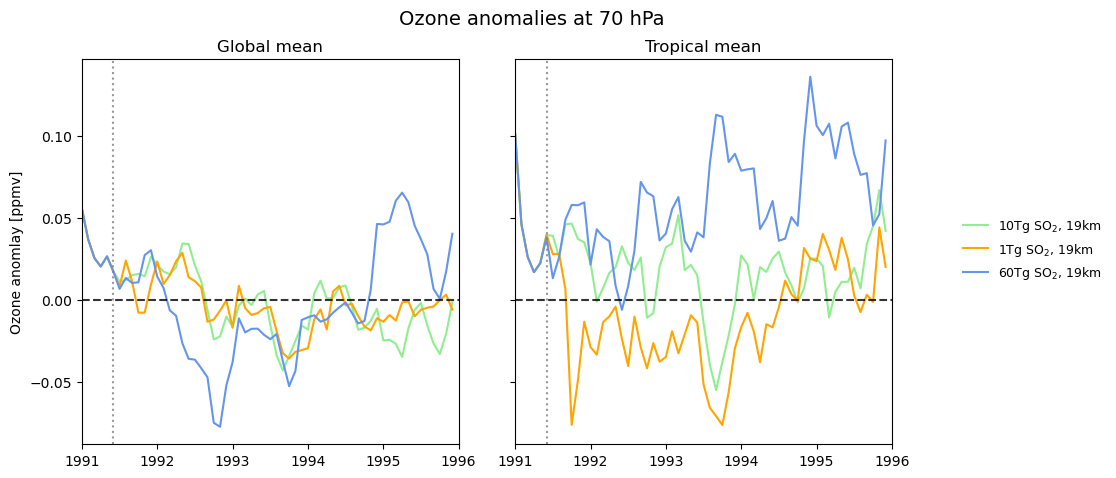

In [49]:
plt.close('all')

t_19_c = [t.year + (t.month-1)/12 for t in o3_19_c_ppmv.time.values]
t_1tg = [t.year + (t.month-1)/12 for t in o3_1tg_ppmv.time.values]
t_60tg = [t.year + (t.month-1)/12 for t in o3_60tg_ppmv.time.values]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#ax[0].fill_between(t_19,
#               0 - 2*o3_glob_std, 
#               0 + 2*o3_glob_std, 
#               color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[0].plot(t_19_c, o3_19_c_ppmv, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(t_1tg, o3_1tg_ppmv, color = "orange", label = "1Tg SO$_2$, 19km")
ax[0].plot(t_60tg, o3_60tg_ppmv, color = "cornflowerblue", label = "60Tg SO$_2$, 19km")

ax[0].set_xlabel("")
ax[0].set_ylabel("Ozone anomlay [ppmv]") 
ax[0].set_title("Global mean", fontsize=12)

#ax[1].fill_between(t_19,
#               0 - 2*o3_trop_std, 
#               0 + 2*o3_trop_std, 
#               color='gray', alpha=0.2, zorder=0, label = "$\pm2\sigma$")
ax[1].plot(t_19_c, o3_19_c_trop_ppmv, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[1].plot(t_1tg, o3_1tg_trop_ppmv, color="orange")
ax[1].plot(t_60tg, o3_60tg_trop_ppmv, color="cornflowerblue")

ax[1].set_xlabel("")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for a in ax:
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)

h, l = ax[0].get_legend_handles_labels()
unique_legend = dict(zip(l, h))

fig.legend(
    unique_legend.values(), 
    unique_legend.keys(), 
    loc="center left", 
    bbox_to_anchor=(0.85, 0.5), 
    frameon=False,
    fontsize=9
)

fig.suptitle("Ozone anomalies at 70 hPa", fontsize=14)
plt.subplots_adjust(right=0.80, wspace=0.15) 

plt.show()

In [50]:
def plot_o3_lev_time_final(ds, weighted_list, base_clim, title, ax, plot_period=("1991-01-01", "1996-01-01"), vmin=-25, vmax=25):
    dims_to_reduce = [d for d in ds["O3"].dims if d not in ["time", "lev"]]
    o3_weighted = ds["O3"].weighted(weighted_list).mean(dim=dims_to_reduce)
    
    dims_base = [d for d in base_clim.dims if d not in ["month", "lev"]]
    base_weighted = base_clim.mean(dim=dims_base)

    o3_anom = ((o3_weighted.groupby("time.month") - base_weighted) / base_weighted) * 100
    
    if "month" in o3_anom.coords:
        o3_anom = o3_anom.drop_vars("month")
    
    o3_plot = o3_anom.sel(time=slice(*plot_period)).squeeze()
    
    if "month" in o3_plot.dims:
        o3_plot = o3_plot.mean(dim="month")

    levels = np.linspace(vmin, vmax, 41)
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    
    im = o3_plot.plot.contourf(
        ax=ax,
        x="time",
        y="lev",
        levels=levels,
        cmap="coolwarm",
        norm=norm,
        add_colorbar=False,
        extend='both'
    )
    
    years = range(int(plot_period[0][:4]), int(plot_period[1][:4]) + 1)
    ax.set_xticks([cftime.DatetimeNoLeap(y, 1, 1) for y in years])
    ax.set_xticklabels([str(y) for y in years])
    ax.set_ylabel(" ")
    ax.set_xlabel(" ")
    ax.set_yscale('log')
    ax.invert_yaxis() 
    
    ss = ax.get_subplotspec()
    if ss.is_first_col():
        ax.set_ylabel("Model level [hPa]", fontsize=12)
    else:
        ax.set_yticklabels([])

    if not ss.is_last_row():
        ax.set_xticklabels([])

    ax.set_title(title, fontsize=12)
    
    return im

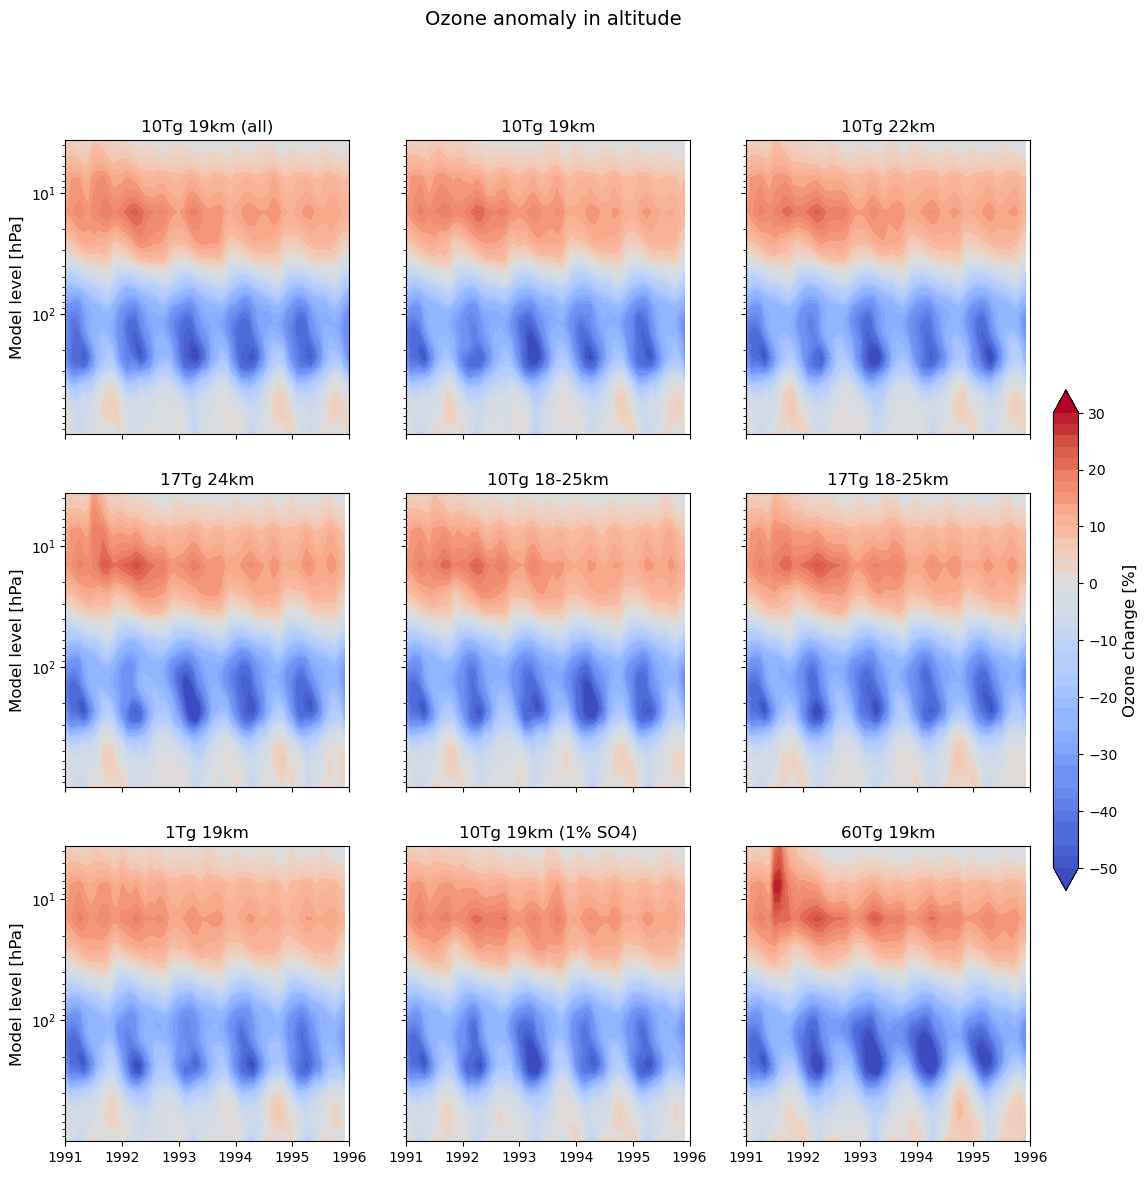

In [51]:
datasets = [O3_19, O3_19_c, O3_22, O3_24, O3_1825, O3_1825_17tg, O3_1tg, O3_1pr, O3_60tg]
titles = ["10Tg 19km (all)", "10Tg 19km", "10Tg 22km", 
          "17Tg 24km", "10Tg 18-25km", "17Tg 18-25km", 
          "1Tg 19km", "10Tg 19km (1% SO4)", "60Tg 19km"]
weights = [weighted_lat,
           weighted_lat_19_c,
           weighted_lat_22, 
           weighted_lat_24, 
           weighted_lat_1825, 
           weighted_lat_1825_17tg, 
           weighted_lat_1tg, 
           weighted_lat_1pr,
           weighted_lat_60tg]

fig, axs = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=False)
#plt.subplots_adjust(right=0.88, hspace=0.3, wspace=0.1)

for ax, ds, title, w in zip(axs.flat, datasets, titles, weights):
    im = plot_o3_lev_time_final(
        ds, 
        weighted_list=w,    
        base_clim=base, 
        title=title, 
        ax=ax, 
        vmin=-50, 
        vmax=30, 
    )

cbar = fig.colorbar(im, ax=axs, location='right', shrink=0.5, pad=0.02, extend='both')
cbar.set_label("Ozone change [%]", fontsize=12)

#plt.tight_layout
fig.suptitle("Ozone anomaly in altitude", fontsize=14, x=0.45)
plt.show()

## Detrending for 30 hPa in the size-dependency experiments

Need to use the standard run from 1975, then append the experimnets in 1991 and onwards. 

In [52]:
switch_date = "1991-01-01"
lev_target = 70

da_std = O3_19["O3"].sel(lev=lev_target, method="nearest").sel(time=slice(None, "1990-12-31"))
da_10  = O3_19_c["O3"].sel(lev=lev_target, method="nearest").sel(time=slice(switch_date, None))
da_1   = O3_1tg["O3"].sel(lev=lev_target, method="nearest").sel(time=slice(switch_date, None))
da_60  = O3_60tg["O3"].sel(lev=lev_target, method="nearest").sel(time=slice(switch_date, None))

ts_std = da_std.weighted(weighted_lat).mean(dim=["lat", "lon"]).compute()
ts_10  = xr.concat([da_std, da_10], dim="time").weighted(weighted_lat).mean(dim=["lat", "lon"]).compute()
ts_1   = xr.concat([da_std, da_1], dim="time").weighted(weighted_lat).mean(dim=["lat", "lon"]).compute()
ts_60  = xr.concat([da_std, da_60], dim="time").weighted(weighted_lat).mean(dim=["lat", "lon"]).compute()

ts_std_det = xr.DataArray(
    signal.detrend(ts_std.values),
    coords=ts_std.coords,
    dims=ts_std.dims,
)

ts_10_det = xr.DataArray(
    signal.detrend(ts_10.values),
    coords=ts_10.coords,
    dims=ts_10.dims,
)

ts_1_det = xr.DataArray(
    signal.detrend(ts_1.values),
    coords=ts_1.coords,
    dims=ts_1.dims,
)

ts_60_det = xr.DataArray(
    signal.detrend(ts_60.values),
    coords=ts_60.coords,
    dims=ts_60.dims,
)

clim_det = ts_std_det.sel(time=slice("1975", "1990")).groupby("time.month").mean()

anom_10 = (ts_10_det.groupby("time.month") - clim_det).sel(time=slice("1991", "1996")) * 1e6
anom_1  = (ts_1_det.groupby("time.month") - clim_det).sel(time=slice("1991", "1996")) * 1e6
anom_60 = (ts_60_det.groupby("time.month") - clim_det).sel(time=slice("1991", "1996")) * 1e6

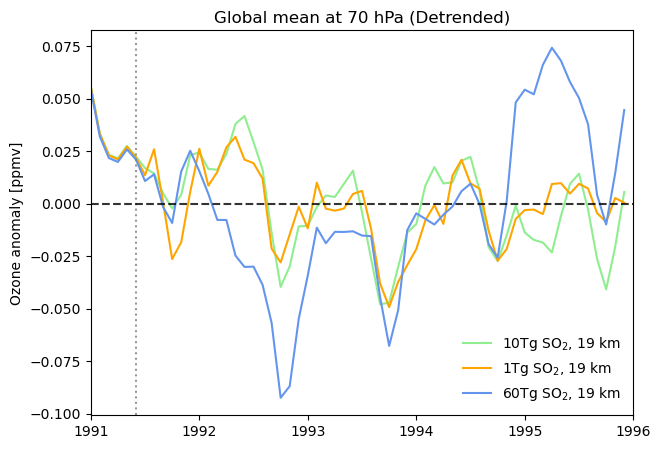

In [53]:
t_10 = [t.year + (t.month - 1)/12 for t in anom_10.time.values]
t_1  = [t.year + (t.month - 1)/12 for t in anom_1.time.values]
t_60 = [t.year + (t.month - 1)/12 for t in anom_60.time.values]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(t_10, anom_10.values, color="lightgreen", label="10Tg SO$_2$, 19 km")
ax.plot(t_1,  anom_1.values,  color="orange", label="1Tg SO$_2$, 19 km")
ax.plot(t_60, anom_60.values, color="cornflowerblue", label="60Tg SO$_2$, 19 km")

ax.axvline(1991 + 5/12, color="gray", ls=":", alpha=0.8)
ax.axhline(0, color="black", ls="--", alpha=0.8)

ax.set_xlim(1991, 1996)
ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_ylabel("Ozone anomaly [ppmv]")
ax.set_title("Global mean at 70 hPa (Detrended)")
ax.legend(frameon=False, loc="best")

plt.show()

### Different mothod, only detrending the standard run between 1975-1990, and then use this as the climatology for anomaly calculation

In [54]:
def global_mean_1level(ds, var="O3", lev=30, weights=None, time_slice=None):
    da = ds[var].sel(lev=lev, method="nearest")

    if time_slice is not None:
        da = da.sel(time=slice(*time_slice))

    return (
        da
        .weighted(weights)
        .mean(dim=["lat", "lon"])
        .compute()
    )


In [55]:
def detrend_1d(ts):
    valid = np.isfinite(ts.values)

    y = ts.values.astype(float)
    out = np.full_like(y, np.nan, dtype=float)

    if valid.sum() >= 2:
        y_valid = y[valid]

        out[valid] = signal.detrend(y_valid) + np.nanmean(y_valid)

    return xr.DataArray(
        out,
        coords=ts.coords,
        dims=ts.dims,
        attrs=ts.attrs,
        name=ts.name
    )

In [56]:
baseline_start = "1975-01-01"
baseline_end   = "1990-12-31"

plot_start = "1991-01-01"
plot_end   = "1995-12-31"

lev_target = 30

ts_std_base = global_mean_1level(
    O3_19,
    var="O3",
    lev=lev_target,
    weights=weighted_lat,
    time_slice=(baseline_start, baseline_end),
)

ts_std_base_det = detrend_1d(ts_std_base)

clim_det = (
    ts_std_base_det
    .groupby("time.month")
    .mean()
    .compute()
)

o3_std = (
    ts_std_base_det
    .groupby("time.month")
    .std()
    .compute()
)

In [57]:

ts_10 = global_mean_1level(
    O3_19_c,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_19_c,
    time_slice=(plot_start, plot_end),
)

ts_1 = global_mean_1level(
    O3_1tg,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_1tg,
    time_slice=(plot_start, plot_end),
)

ts_60 = global_mean_1level(
    O3_60tg,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_60tg,
    time_slice=(plot_start, plot_end),
)

anom_10 = (ts_10.groupby("time.month") - clim_det) * 1e6
anom_1  = (ts_1.groupby("time.month")  - clim_det) * 1e6
anom_60 = (ts_60.groupby("time.month") - clim_det) * 1e6

if "month" in anom_10.coords:
    anom_10 = anom_10.drop_vars("month")
if "month" in anom_1.coords:
    anom_1 = anom_1.drop_vars("month")
if "month" in anom_60.coords:
    anom_60 = anom_60.drop_vars("month")

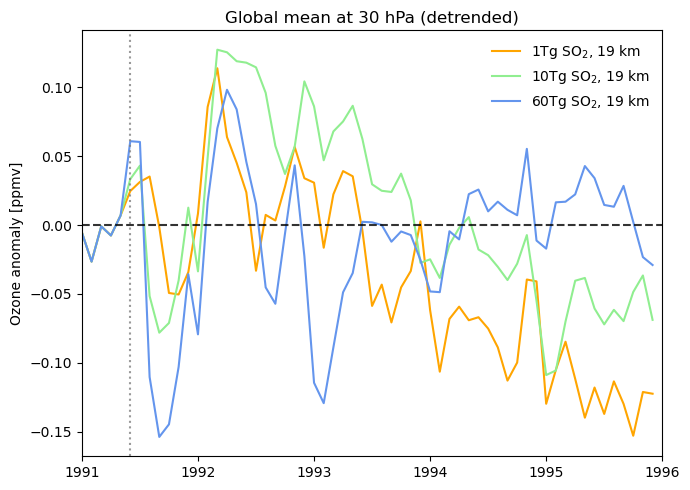

In [58]:
t_10 = [t.year + (t.month - 1) / 12 for t in anom_10.time.values]
t_1  = [t.year + (t.month - 1) / 12 for t in anom_1.time.values]
t_60 = [t.year + (t.month - 1) / 12 for t in anom_60.time.values]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(t_1,  anom_1.values,  color="orange", label="1Tg SO$_2$, 19 km")
ax.plot(t_10, anom_10.values, color="lightgreen", label="10Tg SO$_2$, 19 km")
ax.plot(t_60, anom_60.values, color="cornflowerblue", label="60Tg SO$_2$, 19 km")

eruption_float = 1991 + 5 / 12

ax.axvline(eruption_float, color="gray", ls=":", alpha=0.8)
ax.axhline(0, color="black", ls="--", alpha=0.8)

ax.set_xlim(1991, 1996)
ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_ylabel("Ozone anomaly [ppmv]")
ax.set_title("Global mean at 30 hPa (detrended)")
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()

In [59]:
def region_mean_1level(ds, var="O3", lev=30, weights=None, lat_range=None, time_slice=None):
    da = ds[var].sel(lev=lev, method="nearest")
    if lat_range is not None:
        da = da.sel(lat=slice(*lat_range))
        weights = weights.sel(lat=slice(*lat_range))
    if time_slice is not None:
        da = da.sel(time=slice(*time_slice))
    return da.weighted(weights).mean(dim=["lat", "lon"]).compute()

lat_range = (-20, 20)

ts_std_trop = region_mean_1level(O3_19, "O3", lev_target, weighted_lat, lat_range, (baseline_start, baseline_end))
ts_10_trop = region_mean_1level(O3_19_c, "O3", lev_target, weighted_lat_19_c, lat_range, (plot_start, plot_end))
ts_1_trop = region_mean_1level(O3_1tg, "O3", lev_target, weighted_lat_1tg, lat_range, (plot_start, plot_end))
ts_60_trop = region_mean_1level(O3_60tg, "O3", lev_target, weighted_lat_60tg, lat_range, (plot_start, plot_end))

ts_std_trop_det = detrend_1d(ts_std_trop)
ts_10_trop_det = detrend_1d(ts_10_trop)
ts_1_trop_det = detrend_1d(ts_1_trop)
ts_60_trop_det = detrend_1d(ts_60_trop)

clim_trop_det = ts_std_trop_det.groupby("time.month").mean()

anom_10_trop = (ts_10_trop_det.groupby("time.month") - clim_trop_det) * 1e6
anom_1_trop = (ts_1_trop_det.groupby("time.month") - clim_trop_det) * 1e6
anom_60_trop = (ts_60_trop_det.groupby("time.month") - clim_trop_det) * 1e6

In [60]:
ctrl_det_anom = (ts_std_det.groupby("time.month") - clim_det).sel(time=slice("1975", "1990")) * 1e6
ctrl_det_std = float(ctrl_det_anom.std().values)

ctrl_trop_det_anom = (ts_std_trop_det.groupby("time.month") - clim_trop_det).sel(time=slice("1975", "1990")) * 1e6
ctrl_trop_det_std = float(ctrl_trop_det_anom.std().values)

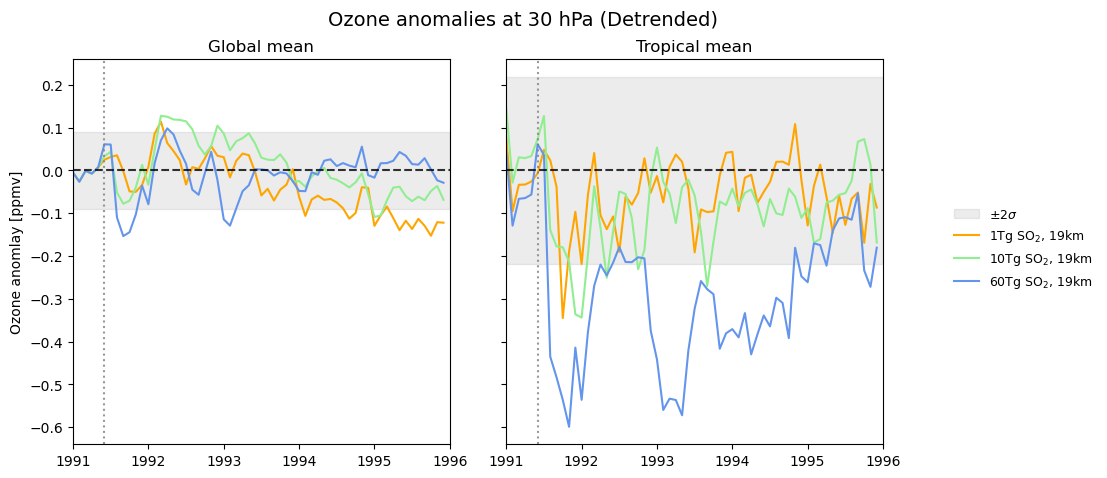

In [61]:
t_10_trop = [t.year + (t.month - 1)/12 for t in anom_10_trop.time.values]
t_1_trop = [t.year + (t.month - 1)/12 for t in anom_1_trop.time.values]
t_60_trop = [t.year + (t.month - 1)/12 for t in anom_60_trop.time.values]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].axhspan(
    -2 * ctrl_det_std,
     2 * ctrl_det_std,
    color="grey",
    alpha=0.15,
    zorder=0,
    label=r"$\pm2\sigma$"
)
ax[0].plot(t_1, anom_1.values, color = "orange", label = "1Tg SO$_2$, 19km")
ax[0].plot(t_10, anom_10.values, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(t_60, anom_60.values, color = "cornflowerblue", label = "60Tg SO$_2$, 19km")

ax[0].set_xlabel("")
ax[0].set_ylabel("Ozone anomlay [ppmv]") 
ax[0].set_title("Global mean", fontsize=12)

ax[1].axhspan(
    -2 * ctrl_trop_det_std,
     2 * ctrl_trop_det_std,
    color="grey",
    alpha=0.15,
    zorder=0
)
ax[1].plot(t_1_trop, anom_1_trop.values , color="orange")
ax[1].plot(t_10_trop, anom_10_trop.values , color="lightgreen", label="10Tg SO$_2$, 19km")
ax[1].plot(t_60_trop, anom_60_trop.values, color="cornflowerblue")

ax[1].set_xlabel("")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for a in ax:
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)

h, l = ax[0].get_legend_handles_labels()
unique_legend = dict(zip(l, h))

fig.legend(
    unique_legend.values(), 
    unique_legend.keys(), 
    loc="center left", 
    bbox_to_anchor=(0.85, 0.5), 
    frameon=False,
    fontsize=9
)

fig.suptitle("Ozone anomalies at 30 hPa (Detrended)", fontsize=14)
plt.subplots_adjust(right=0.80, wspace=0.15) 

plt.show()

In [62]:
ts_19 = global_mean_1level(
    O3_19,
    var="O3",
    lev=lev_target,
    weights=weighted_lat,
    time_slice=(plot_start, plot_end),
)

ts_22 = global_mean_1level(
    O3_22,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_22,
    time_slice=(plot_start, plot_end),
)

ts_24 = global_mean_1level(
    O3_24,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_24,
    time_slice=(plot_start, plot_end),
)

ts_1825 = global_mean_1level(
    O3_1825,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_1825,
    time_slice=(plot_start, plot_end),
)

ts_1825_17tg = global_mean_1level(
    O3_1825_17tg,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_1825_17tg,
    time_slice=(plot_start, plot_end),
)

ts_1pr = global_mean_1level(
    O3_1pr,
    var="O3",
    lev=lev_target,
    weights=weighted_lat_1pr,
    time_slice=(plot_start, plot_end),
)

In [63]:
plot_start = "1991-01"
plot_end   = "1995-12"

anom_19 = (
    (ts_19.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

anom_22 = (
    (ts_22.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

anom_24 = (
    (ts_24.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

anom_1825 = (
    (ts_1825.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

anom_1825_17tg = (
    (ts_1825_17tg.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

anom_1pr = (
    (ts_1pr.sel(time=slice(plot_start, plot_end)).groupby("time.month") - clim_det)
    * 1e6
)

In [64]:
t_19 = [t.year + (t.month - 1) / 12 for t in anom_19.time.values]
t_22  = [t.year + (t.month - 1) / 12 for t in anom_22.time.values]
t_24 = [t.year + (t.month - 1) / 12 for t in anom_24.time.values]
t_1825 = [t.year + (t.month - 1) / 12 for t in anom_1825.time.values]
t_1825_17tg  = [t.year + (t.month - 1) / 12 for t in anom_1825_17tg.time.values]
t_1pr = [t.year + (t.month - 1) / 12 for t in anom_1pr.time.values]

In [65]:
ts_19_trop = region_mean_1level(
    O3_19, "O3", lev_target, weighted_lat, lat_range,
    (baseline_start, baseline_end)
)

ts_22_trop = region_mean_1level(
    O3_22, "O3", lev_target, weighted_lat_22, lat_range,
    (plot_start, plot_end)
)

ts_24_trop = region_mean_1level(
    O3_24, "O3", lev_target, weighted_lat_24, lat_range,
    (plot_start, plot_end)
)

ts_1825_trop = region_mean_1level(
    O3_1825, "O3", lev_target, weighted_lat_1825, lat_range,
    (plot_start, plot_end)
)

ts_1825_17tg_trop = region_mean_1level(
    O3_1825_17tg, "O3", lev_target, weighted_lat_1825_17tg, lat_range,
    (plot_start, plot_end)
)

ts_1pr_trop = region_mean_1level(
    O3_1pr, "O3", lev_target, weighted_lat_1pr, lat_range,
    (plot_start, plot_end)
)

In [66]:
ts_19_trop_det = detrend_1d(ts_19_trop)

clim_trop_det = (
    ts_19_trop_det
    .groupby("time.month")
    .mean()
    .compute()
)

o3_trop_std = (
    ts_19_trop_det
    .groupby("time.month")
    .std()
    .compute()
)

In [67]:
anom_19_trop = (ts_19_trop.groupby("time.month") - clim_trop_det) * 1e6
anom_22_trop = (ts_22_trop.groupby("time.month") - clim_trop_det) * 1e6
anom_24_trop = (ts_24_trop.groupby("time.month") - clim_trop_det) * 1e6
anom_1825_trop = (ts_1825_trop.groupby("time.month") - clim_trop_det) * 1e6
anom_1825_17tg_trop = (ts_1825_17tg_trop.groupby("time.month") - clim_trop_det) * 1e6
anom_1pr_trop = (ts_1pr_trop.groupby("time.month") - clim_trop_det) * 1e6

In [68]:
t_19_trop = [t.year + (t.month - 1) / 12 for t in anom_19_trop.time.values]
t_22_trop  = [t.year + (t.month - 1) / 12 for t in anom_22_trop.time.values]
t_24_trop = [t.year + (t.month - 1) / 12 for t in anom_24_trop.time.values]
t_1825_trop = [t.year + (t.month - 1) / 12 for t in anom_1825_trop.time.values]
t_1825_17tg_trop  = [t.year + (t.month - 1) / 12 for t in anom_1825_17tg_trop.time.values]
t_1pr_trop = [t.year + (t.month - 1) / 12 for t in anom_1pr_trop.time.values]

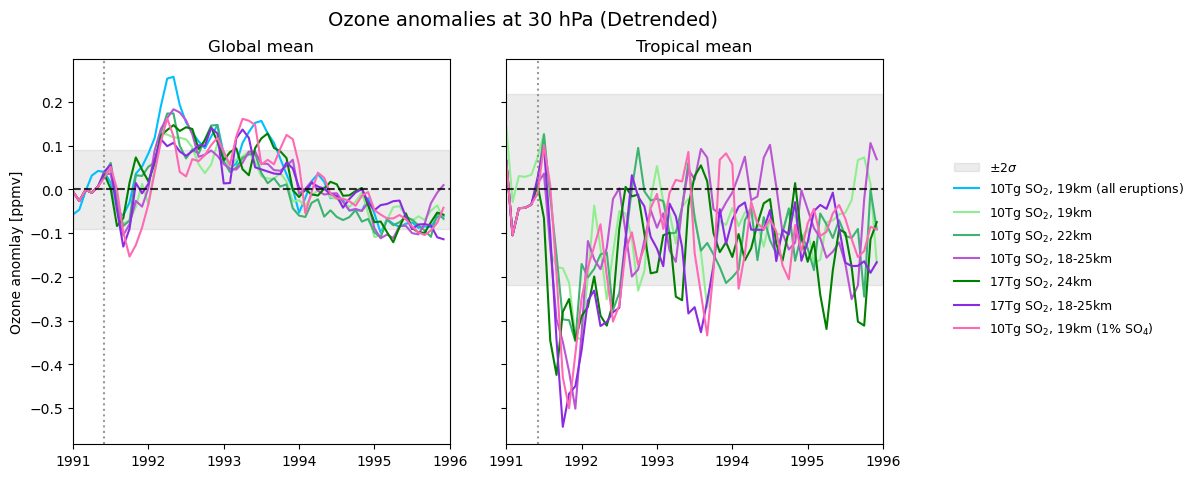

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].axhspan(
    -2 * ctrl_det_std,
     2 * ctrl_det_std,
    color="grey",
    alpha=0.15,
    zorder=0,
    label=r"$\pm2\sigma$"
)

ax[0].plot(t_19, anom_19.values, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_10, anom_10.values, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_22, anom_22.values, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[0].plot(t_1825, anom_1825.values, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[0].plot(t_24, anom_24.values, color = "green", label = "17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg, anom_1825_17tg.values, color = "blueviolet", label = "17Tg SO$_2$, 18-25km")
ax[0].plot(t_1pr, anom_1pr.values, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
ax[0].set_xlabel("")
ax[0].set_ylabel("Ozone anomlay [ppmv]") 
ax[0].set_title("Global mean", fontsize=12)

ax[1].axhspan(
    -2 * ctrl_trop_det_std,
     2 * ctrl_trop_det_std,
    color="grey",
    alpha=0.15,
    zorder=0
)
ax[1].plot(t_19_trop, anom_19_trop.values, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_10_trop, anom_10_trop.values, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_22_trop, anom_22_trop.values, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[1].plot(t_1825_trop, anom_1825_trop.values, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[1].plot(t_24_trop, anom_24_trop.values, color = "green", label = "17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg_trop, anom_1825_17tg_trop.values, color = "blueviolet", label =  "17Tg SO$_2$, 18-25km")
ax[1].plot(t_1pr_trop, anom_1pr_trop.values, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
ax[1].set_xlabel("")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for a in ax:
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    a.set_xlim(1991, 1996)

h, l = ax[0].get_legend_handles_labels()
unique_legend = dict(zip(l, h))

fig.legend(
    unique_legend.values(), 
    unique_legend.keys(), 
    loc="center left", 
    bbox_to_anchor=(0.85, 0.5), 
    frameon=False,
    fontsize=9
)

fig.suptitle("Ozone anomalies at 30 hPa (Detrended)", fontsize=14)
plt.subplots_adjust(right=0.80, wspace=0.15) 

plt.show()